In [1]:
import pandas as pd
import numpy as np
import optuna
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import math as mt
import shap
import json
from optbinning import BinningProcess, OptimalBinning
from sklearn.linear_model import LogisticRegression as LR
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import (train_test_split, KFold, GridSearchCV,
                                      StratifiedKFold, TimeSeriesSplit)
from optuna.samplers import TPESampler

(CVXPY) May 07 08:00:28 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) May 07 08:00:28 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


## 1. Загрузка набора данных

Исходными данными служит набор данных **Home Credit Default Risk** (платформа Kaggle), дополненный синтетически сгенерированным причинно-следственным слоем коммуникационных воздействий: SMS, звонок робота, звонок оператора. Полная процедура генерации описана в ноутбуке `prepare_dataset.ipynb` и главе 2 диссертации.

**Состав файла `uplift-dataset.csv`:**
- **307 511 наблюдений** — заявки на потребительский кредит
- **173 признака** — социально-демографические характеристики, параметры кредитного договора, данные бюро кредитных историй
- **Исходная целевая переменная `TARGET`** — бинарный индикатор дефолта в исходном наборе Home Credit. В моделировании данного ноутбука используется `TARGET_AFTER_CONTACT`, то есть наблюдаемый исход после синтетически заданной политики коммуникаций.
- **Синтетические переменные** (`BASE_PD`, `COMMUNICATION`, `TRUE_UPLIFT`, `TARGET_AFTER_CONTACT` и др.) — сгенерированы для моделирования причинно-следственного эффекта коммуникационного воздействия; в обучение модели кредитного риска не включаются

Все пути к данным заданы относительно корня репозитория для воспроизводимости при запуске на любой машине.

In [2]:
import os

DATA_PATH = "data/processed"  # обработанные данные
MODELS_PATH = "models/logreg"  # сохранение модели

os.makedirs(MODELS_PATH, exist_ok=True)

In [3]:
RANDOM_SEED = 91

In [4]:
np.random.seed(RANDOM_SEED)

In [5]:
df = pd.read_csv(DATA_PATH + "/uplift-dataset.csv")

print("Размерность набора данных:", df.shape)

Dataset shape: (307511, 173)


## 2. Первичный осмотр данных

На этом этапе выполняется диагностика набора данных: проверка размерности, типов данных, доли пропущенных значений и распределения целевой переменной.

**Дисбаланс классов и выбор метрики.** При доле дефолтов ~8% традиционные метрики качества (точность, $F_1$-мера) смещены в пользу мажоритарного класса. В кредитном моделирование кредитного рискае стандартной метрикой является **нормализованный коэффициент Джини**:

$$G = 2 \cdot \text{площадь под ROC-кривой (AUC)} - 1, \quad G \in [-1,\, 1]$$

где $\text{площадь под ROC-кривой (AUC)}$ — площадь под ROC-кривой. При $G = 0$ модель неотличима от случайного классификатора; при $G = 1$ — идеальна. В розничном кредитовании моделями с $G > 0{,}40$ считаются хорошими, $G > 0{,}55$ — сильными.

**Пропуски:** значительная часть переменных имеет долю пропусков от 30% до 80%. Переменные с долей пропусков выше порога `MAX_MISSING_RATIO = 0.8` удаляются на этапе предобработки (раздел 4). Для оставшихся числовых признаков применяется медианная импутация; для категориальных — заполнение меткой `'NaN'`.

In [6]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,PD_OPERATOR_CALL,UPLIFT_SMS,UPLIFT_ROBOT_CALL,UPLIFT_OPERATOR_CALL,TRUE_UPLIFT,ORACLE_COMMUNICATION,ORACLE_TRUE_UPLIFT,ORACLE_PD_AFTER_CONTACT,PD_AFTER_CONTACT,TARGET_AFTER_CONTACT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.671466,0.021933,0.016229,-0.005122,-0.005122,operator_call,-0.005122,0.671466,0.671466,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.047954,0.008737,-0.022656,0.000660,0.000000,robot_call,-0.022656,0.024638,0.047294,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.008536,-0.010511,-0.003049,0.002265,0.000000,sms,-0.006270,0.000000,0.006270,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.014554,-0.005826,0.001288,-0.000989,0.000000,sms,-0.005826,0.009717,0.015543,0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.080671,0.005212,-0.004084,-0.019559,0.000000,operator_call,-0.019559,0.080671,0.100230,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.069975,0.021921,-0.009142,-0.027362,0.000000,operator_call,-0.027362,0.069975,0.097337,0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.077837,0.018272,-0.001632,-0.023324,0.000000,operator_call,-0.023324,0.077837,0.101161,0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.016405,-0.014803,0.003480,0.001136,0.000000,sms,-0.014803,0.000467,0.015270,0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.017641,0.000952,-0.007578,-0.006032,0.000000,robot_call,-0.007578,0.016094,0.023673,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 173 entries, SK_ID_CURR to TARGET_AFTER_CONTACT
dtypes: float64(109), int64(44), object(20)
memory usage: 405.9+ MB


In [8]:
df['TARGET'].value_counts(normalize=True).round(4) * 100

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

In [9]:
df['TARGET_AFTER_CONTACT'].value_counts(normalize=True).round(4) * 100

TARGET_AFTER_CONTACT
0    92.27
1     7.73
Name: proportion, dtype: float64

In [10]:
dt_cols = df.select_dtypes(include=['datetime64']).columns.to_list()
object_cols = df.select_dtypes(include=['object']).columns.to_list()
num_cols = df.select_dtypes(include=['number']).columns.to_list()
flg_cols = [col for col in df.columns if col.startswith("FLAG_")] + [
    "LIVE_CITY_NOT_WORK_CITY",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION"
]


target = "TARGET_AFTER_CONTACT"

uplift_cols = [
  "BASE_PD",
  "CONTACT_PROPENSITY",
  "COMMUNICATION",
  "RISK_SEGMENT",
  "CONTACT_HISTORY",
  "PREFERRED_CHANNEL",
  "INTERACTION_SCORE",
  "DELAY_FLAG",
  "PD_NO_CONTACT",
  "PD_SMS",
  "PD_ROBOT_CALL",
  "PD_OPERATOR_CALL",
  "UPLIFT_SMS",
  "UPLIFT_ROBOT_CALL",
  "UPLIFT_OPERATOR_CALL",
  "TRUE_UPLIFT",
  "PD_AFTER_CONTACT",
  "ORACLE_COMMUNICATION",
  "ORACLE_TRUE_UPLIFT",
  "ORACLE_PD_AFTER_CONTACT",
  # Внешние моделирование кредитного рискаовые оценки: проприетарные данные кредитных бюро,
  # в реальных продакшн-системах зачастую недоступны
  "EXT_SOURCE_1",
  "EXT_SOURCE_2",
  "EXT_SOURCE_3",
]


num_cols = sorted(list(set(num_cols) - set(flg_cols)))
num_cols = [c for c in num_cols if c not in ('TARGET', 'TARGET_AFTER_CONTACT')]

In [11]:
dt_cols

[]

In [12]:
object_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE',
 'RISK_SEGMENT',
 'PREFERRED_CHANNEL',
 'COMMUNICATION',
 'ORACLE_COMMUNICATION']

In [13]:
num_cols

['AMT_ANNUITY',
 'AMT_APPLICATION_MAX',
 'AMT_APPLICATION_MEAN',
 'AMT_BALANCE_MAX',
 'AMT_BALANCE_MEAN',
 'AMT_CREDIT',
 'AMT_CREDIT_LIMIT_ACTUAL_MEAN',
 'AMT_CREDIT_MAX',
 'AMT_CREDIT_MEAN',
 'AMT_CREDIT_SUM_DEBT_MEAN',
 'AMT_CREDIT_SUM_DEBT_SUM',
 'AMT_CREDIT_SUM_MEAN',
 'AMT_CREDIT_SUM_OVERDUE_SUM',
 'AMT_CREDIT_SUM_SUM',
 'AMT_DRAWINGS_CURRENT_MEAN',
 'AMT_GOODS_PRICE',
 'AMT_INCOME_TOTAL',
 'AMT_INSTALMENT_MEAN',
 'AMT_PAYMENT_MEAN',
 'AMT_PAYMENT_SUM',
 'AMT_REQ_CREDIT_BUREAU_DAY',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'APARTMENTS_AVG',
 'APARTMENTS_MEDI',
 'APARTMENTS_MODE',
 'BASEMENTAREA_AVG',
 'BASEMENTAREA_MEDI',
 'BASEMENTAREA_MODE',
 'BASE_PD',
 'CNT_CHILDREN',
 'CNT_FAM_MEMBERS',
 'CNT_INSTALMENT_FUTURE_MEAN',
 'CNT_INSTALMENT_MEAN',
 'CNT_PAYMENT_MEAN',
 'COMMONAREA_AVG',
 'COMMONAREA_MEDI',
 'COMMONAREA_MODE',
 'CONTACT_HISTORY',
 'CONTACT_PROPENSITY',
 '

In [14]:
flg_cols

['FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21',
 'LIVE_CITY_NOT_WORK_CITY',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION']

## 3. Генерация производных признаков

На основе исходных переменных формируются инженерные признаки, несущие содержательный смысл в контексте кредитного риска:

$$\text{AGE\_YEARS} = \frac{|\text{DAYS\_BIRTH}|}{365}$$

— возраст клиента в годах; молодой возраст статистически связан с более высокой вероятностью дефолта.

$$\text{EMPLOYMENT\_RATIO} = \frac{\text{DAYS\_EMPLOYED}}{\text{DAYS\_BIRTH}}$$

— доля занятого времени к возрасту; косвенно отражает стабильность занятости.

$$\text{CREDIT\_HISTORY\_LENGTH} = \frac{|\text{DAYS\_FIRST\_DRAWING}|}{365}$$

— продолжительность кредитной истории в годах; более длинная история снижает неопределённость при оценке.

$$\text{ANNUITY\_TO\_INCOME} = \frac{\text{AMT\_ANNUITY}}{\text{AMT\_INCOME\_TOTAL}}$$

— долговая нагрузка; высокое значение сигнализирует о недостаточной платёжеспособности.

In [15]:
# Возраст в годах
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

# Стаж работы
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365

# Доля стажа от возраста
df["EMPLOYMENT_RATIO"] = df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]

# Давность кредитной истории
df["CREDIT_HISTORY_LENGTH"] = (
    df["DAYS_CREDIT_MAX"] - df["DAYS_CREDIT_MIN"]
)

# Активность по кредитке
df["MONTHS_BALANCE_RANGE"] = (
    df["MONTHS_BALANCE_MIN"] - df["MONTHS_BALANCE_MEAN"]
)

## 4. Предобработка набора данных

Конвейер предобработки включает четыре последовательных шага:

1. **Приведение типов** (`transform_to_standart_types`): категориальные переменные переводятся в `str`, целочисленные признаки приводятся к `float64` для совместимости с `BinningProcess`.

2. **Заполнение пропусков в категориальных переменных** (`fillna_categorical`): все `NaN`, `None`, `N/A` заменяются специальной меткой `'NaN'`, которую `OptimalBinning` обрабатывает как отдельную категорию.

3. **Удаление ненужных переменных** (`drop_unnecessary_columns`): исключаются идентификатор `SK_ID_CURR`, переменные с долей пропусков > `MAX_MISSING_RATIO = 0.8` и константные признаки (`nunique < 2`).

4. **Числовая импутация**: медиана по обучающей выборке, применяется ко всем числовым переменным.

Вся предобработка реализована без утечки данных: параметры (медианы, WoE-границы) вычисляются только на обучающей подвыборке и применяются к остальным.

In [16]:
def transform_to_standart_types(df: pd.DataFrame) -> pd.DataFrame:
    """
    Приводит все колонки таблицы данных к стандартным типам данных.

    Категориальные (object) переменные переводятся в `str`; `NaN` заменяется
    строкой `'NaN'`. Целочисленные (`int64`) колонки приводятся к `float64`
    для совместимости с `BinningProcess`.

    Параметры
    ----------
    df : pd.DataFrame
        Таблица данных с исходными данными.

    Возвращает
    ----------
    pd.DataFrame
        Таблица данных с приведёнными типами.
    """

    cat_features = df.select_dtypes(object).columns.to_list()

    df[cat_features] = df[cat_features].replace(np.nan, 'NaN')

    for feature in cat_features:
        df[feature] = df[feature].astype(str)

    for col in df.select_dtypes(include=[np.int64]).columns.to_list():
        df[col] = df[col].astype(np.float64)

    return df

def fillna_categorical(df: pd.DataFrame) -> pd.DataFrame:
    """
    Заполняет пропуски в категориальных переменных специальной меткой.

    Все значения `NaN`, `None`, `N/A` заменяются строкой `'NaN'`, которую
    `OptimalBinning` обрабатывает как отдельную категорию, не теряя
    информацию о факте пропуска.

    Параметры
    ----------
    df : pd.DataFrame
        Таблица данных с исходными данными.

    Возвращает
    ----------
    pd.DataFrame
        Таблица данных с заполненными пропусками в категориальных колонках.
    """

    cat_features = df.select_dtypes(object).columns.to_list()

    df[cat_features] = df[cat_features].fillna('NaN')
    df[cat_features] = df[cat_features].replace([np.nan, 'None', 'N/A'], 'NaN')

    return df

def drop_unnecessary_columns(df: pd.DataFrame, max_missing_ratio=0.8) -> pd.DataFrame:
    """
    Удаляет идентификаторы, константные и высоко-пропущенные переменные.

    Три критерия исключения:
    1. Список технических идентификаторов (`SK_ID_CURR`).
    2. Доля пропусков > `max_missing_ratio` (по умолчанию 80%).
    3. Число уникальных значений < 2 (константные признаки).

    Параметры
    ----------
    df : pd.DataFrame
        Таблица данных с исходными данными.
    max_missing_ratio : float, default 0.8
        Максимально допустимая доля пропущенных значений.

    Возвращает
    ----------
    pd.DataFrame
        Таблица данных с удалёнными ненужными колонками.
    """

    unnecessary_columns = ['SK_ID_CURR']

    for col in unnecessary_columns:
        if col in df.columns:
            df = df.drop(col, axis=1)

    missing_ratio = df.isna().mean()
    high_missing_ratio = missing_ratio[missing_ratio > max_missing_ratio].index.to_list()
    df = df.drop(high_missing_ratio, axis=1)

    constant_columns = df.nunique(dropna=False).to_frame()
    constant_columns = constant_columns[constant_columns[0] < 2].index.to_list()
    df = df.drop(constant_columns, axis=1)

    return df

In [17]:
X = df.drop(columns=target).copy()
y = df[target].copy()

In [18]:
X = fillna_categorical(X)
X = transform_to_standart_types(X)

In [19]:
X = drop_unnecessary_columns(X)

In [20]:
filtred_cols = X.columns.tolist()

> **Примечание.** Для построения модели кредитного риска используются исходные числовые и категориальные признаки клиентов после предобработки. Синтетические uplift-переменные (`TRUE_UPLIFT`, `BASE_PD`, `COMMUNICATION`, `CONTACT_PROPENSITY` и др.) в обучение **не включаются** — они используются только в разделе 13 для оценки качества модели как uplift-ранжировщика.

In [21]:
corr = df[num_cols].corrwith(df["TARGET"]).abs().sort_values(ascending=False).round(2)

In [22]:
corr

EXT_SOURCE_3                  0.18
PD_SMS                        0.17
PD_AFTER_CONTACT              0.17
PD_NO_CONTACT                 0.17
BASE_PD                       0.17
                              ... 
AMT_REQ_CREDIT_BUREAU_QRT     0.00
NONLIVINGAPARTMENTS_MODE      0.00
AMT_REQ_CREDIT_BUREAU_HOUR    0.00
AMT_REQ_CREDIT_BUREAU_WEEK    0.00
AMT_CREDIT_SUM_DEBT_MEAN      0.00
Length: 119, dtype: float64

In [23]:
print(f'Из исходных {len(df.columns.tolist())} переменных для построения будем рассматривать {len(filtred_cols)}')

Из исходных 178 переменных для построения будем рассматривать 176


## 5. Разделение данных на обучающую, тестовую и вневременную выборки

Данные делятся на три непересекающихся подмножества **до** любого этапа отбора признаков или обучения — это исключает утечку информации из тестовых выборок в процесс разработки модели.

| Выборка | Доля | N наблюдений | Назначение |
|---|---|---|---|
| **Вневременная (out-of-time, OOT)** | 20% | ~61 500 | Финальная оценка: имитирует применение модели на данных «будущего периода» |
| **Обучающая** | 60% | ~184 500 | Обучение модели и подбор гиперпараметров |
| **Тестовая** | 20% | ~61 500 | Независимая оценка качества в процессе разработки |

Разбивка **стратифицирована** по целевой переменной (`stratify=target`), что сохраняет равную долю дефолтов ~8% в каждой выборке:

$$P(\text{TARGET}=1 \mid \text{split}) \approx 8\% \quad \forall\, \text{split} \in \{\text{train, test, вневременная выборка (OOT)}\}$$

**Вневременная выборка (out-of-time, OOT).** Скоринговая модель применяется на данных, хронологически более поздних, чем обучающие. вневременная выборка (OOT) имитирует это условие: близкое качество на тестовой и вневременной выборках (OOT) (тестовая выборка ≈ вневременная выборка) свидетельствует о временно́й устойчивости модели.

Параметр `random_state=RANDOM_SEED` обеспечивает воспроизводимость разбивки.

In [24]:
data = X.copy()
data[target] = y.copy()

In [25]:
oot_size   = mt.ceil(len(data) * 0.2)
train_test = data[: len(data) - oot_size].copy(deep=True)
oot        = data[len(data) - oot_size :].copy(deep=True)

X_train, X_test, y_train, y_test = train_test_split(
    train_test.drop(columns=target), train_test[target],
    test_size=0.25, stratify=train_test[target],
    random_state=RANDOM_SEED)

X_oot, y_oot = oot.drop(columns=target), oot[target]

train = X_train.copy()
train[target] = y_train

test = X_test.copy()
test[target] = y_test

In [26]:
print(f'Доля наблюдений в обучающей выборке: {len(X_train)/len(data) * 100:.2f}%')
print(f'Доля наблюдений в тестовой выборке: {len(X_test)/len(data) * 100:.2f}%')
print(f'Доля наблюдений во вневременной выборке: {len(X_oot)/len(data) * 100:.2f}%')

Доля наблюдений на train: 60.00%
Доля наблюдений на test: 20.00%
Доля наблюдений на oot: 20.00%


In [27]:
print(f'Общее количество наблюдений: {len(data)}')
print(f'Количество наблюдений в обучающей выборке: {len(X_train)}')
print(f'Количество наблюдений в тестовой выборке: {len(X_test)}')
print(f'Количество наблюдений во вневременной выборке: {len(X_oot)}')

Общее количество наблюдений: 307511
Количество наблюдений на train: 184506
Количество наблюдений на test: 61502
Количество наблюдений на oot: 61503


In [28]:
print(f'Общая доля дефолтов на всех данных: {round(data[target].mean() * 100, 4)}%')
print(f'Доля дефолтов в обучающей выборке: {round(y_train.mean() * 100, 4)}%')
print(f'Доля дефолтов в тестовой выборке: {round(y_test.mean() * 100, 4)}%')
print(f'Доля дефолтов во вневременной выборке: {round(y_oot.mean() * 100, 4)}%')

Общий BR на всех данных: 7.7292%
BR на train: 7.7233%
BR на test: 7.7233%
BR на oot: 7.7525%


---

## 6. Отбор признаков

Отбор признаков для логистической регрессии выполняется в три последовательных этапа, что обусловлено спецификой WoE-вычислительная процедураа:

**Этап 1. Фильтрация по IV и Solo Gini** — независимая предсказательная сила каждой переменной:

$$\text{IV}_j = \sum_{i=1}^{K} \bigl( p_{ij}^{\text{bad}} - p_{ij}^{\text{good}} \bigr) \cdot \text{WoE}_{ij}, \quad \text{WoE}_{ij} = \ln\frac{p_{ij}^{\text{good}}}{p_{ij}^{\text{bad}}}$$

где $p_{ij}^{\text{bad}}$ и $p_{ij}^{\text{good}}$ — доли дефолтных и бездефолтных клиентов в $i$-м бине переменной $j$. Порог отсечения: IV < 0.005.

**Этап 2. WoE-кодирование и корреляционная фильтрация** — устранение мультиколлинеарности. Для логистической регрессии применяется строгий порог корреляции Пирсона 0.35 (для CatBoost — 0.8): линейные классификаторы чувствительны к мультиколлинеарности, поскольку коррелированные признаки завышают дисперсию коэффициентов и дестабилизируют модель.

**Этап 3. Пошаговый отбор (пошаговый отбор признаков (Stepwise Selection))** — жадное добавление переменных по убыванию вклада в коэффициент Джини на кросс-валидации.

In [29]:
features = [f for f in train.columns if f not in ('TARGET', target)]

In [30]:
len(features)

175

In [31]:
features = [col for col in features if col not in uplift_cols]
cat_features = train[features].select_dtypes(['category', 'object']).columns.to_list()


### 6.1 Информационная ценность (IV) и Solo Gini

#### Информационная ценность (Information Value, IV)

IV измеряет, насколько хорошо бинаризованный признак разделяет «хороших» и «плохих» заёмщиков:

$$\text{IV}_j = \sum_{i=1}^{K} \bigl( p_{ij}^{\text{bad}} - p_{ij}^{\text{good}} \bigr) \cdot \text{WoE}_{ij}, \quad \text{WoE}_{ij} = \ln\frac{p_{ij}^{\text{good}}}{p_{ij}^{\text{bad}}}$$

где $p_{ij}^{\text{bad}} = n_{ij}^{\text{bad}} / N^{\text{bad}}$, $p_{ij}^{\text{good}} = n_{ij}^{\text{good}} / N^{\text{good}}$ — доли дефолтных и бездефолтных клиентов в $i$-м бине переменной $j$.

**Практическая интерпретация IV:**

| IV | Предсказательная сила |
|---|---|
| < 0.005 | Бесполезная переменная |
| 0.005–0.02 | Слабая |
| 0.02–0.1 | Средняя |
| 0.1–0.3 | Сильная |
| > 0.3 | Очень сильная (риск «засветки» целевая переменнаяа) |

#### Solo Gini

одиночного коэффициента Джини (Solo Gini) — нормализованный Gini-коэффициент логистической регрессии, обученной **только на одном признаке**:

$$G^{\text{solo}}_j = 2 \cdot \text{площадь под ROC-кривой (AUC)}_j - 1$$

Используется как дополнительная проверка: признак может иметь низкий IV (из-за нелинейности, которую WoE не улавливает) и при этом хороший одиночного коэффициента Джини (Solo Gini). Порог отсечения: $G^{\text{solo}} < 0.05$.

In [32]:
def get_iv(df, feature, y, bins=None):
    """
    Вычисляет информационную ценность (Information Value, IV) признака.

    IV измеряет предсказательную силу признака через WoE-статистику:

        IV = sum_i (p_i_bad - p_i_good) * WoE_i

    где WoE_i = ln(p_i_good / p_i_bad), p_i_bad и p_i_good — доли
    дефолтных и бездефолтных клиентов в i-м бине.

    Параметры
    ----------
    df : pd.DataFrame
        Таблица данных для вычисления IV.
    feature : str
        Название признака.
    y : array-like
        Бинарные истинные метки (1 — дефолт, 0 — норма).
    bins : int or None
        Число бинов для числовых признаков; None — использовать
        уникальные значения как есть (категориальные).

    Возвращает
    ----------
    float
        Значение IV признака.
    """
    lst = []
    target = 'y'
    df[target] = y
    if bins:
        df[feature] = pd.cut(df[feature], bins=bins)

    unique_values = df[feature].unique()
    for val in unique_values:
        lst.append([feature,
                    val,
                    df[(df[feature] == val) & (df[target] == 0)].count()[feature],  # хорошие
                    df[(df[feature] == val) & (df[target] == 1)].count()[feature]   # плохие
                    ])

    data = pd.DataFrame(lst, columns=['Variable', 'Value', 'Good', 'Bad'])

    total_bad = df[df[target] == 1].count()[feature]
    total_good = df.shape[0] - total_bad

    data['Distribution Good'] = data['Good']/ total_good
    data['Distribution Bad'] = data['Bad'] / total_bad
    data['WoE'] = np.log(data['Distribution Good'] / data['Distribution Bad'])

    data = data.replace({'WoE': {np.inf: 0, -np.inf: 0}})

    data['IV'] = data['WoE'] * (data['Distribution Good'] - data['Distribution Bad'])

    data = data.sort_values(by=['Variable', 'Value'], ascending=[True, True])
    data.index = range(len(data.index))

    iv = data['IV'].sum()

    return iv

In [33]:
iv_df = list()

for col in tqdm(features):
    if col not in cat_features + flg_cols:
        iv = get_iv(train.copy(), col, train[target].copy(), bins=10)
    else:
        iv = get_iv(train.copy(), col, train[target].copy())
    iv_df.append({"var": col, "iv": iv})

iv_df = pd.DataFrame(iv_df)


 76%|███████▋  | 116/152 [00:49<00:14,  2.45it/s]c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
 82%|████████▏ | 124/152 [00:53<00:11,  2.40it/s]c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
 89%|████████▉ | 136/152 [00:59<00:08,  1.91it/s]c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
100%|██████████| 152/152 [01:06<00:00,  2.30it/s]


In [34]:
iv_df

,var,iv
0,NAME_CONTRACT_TYPE,0.005910
1,CODE_GENDER,0.017536
2,FLAG_OWN_CAR,0.000673
3,FLAG_OWN_REALTY,0.006232
4,CNT_CHILDREN,0.003397
...,...,...
147,AGE_YEARS,0.163877
148,EMPLOYMENT_YEARS,0.032245
149,EMPLOYMENT_RATIO,0.035943
150,CREDIT_HISTORY_LENGTH,0.038997


In [35]:
filtred_features = iv_df[iv_df['iv'] > 0.005]['var'].values.tolist()

filtred_iv_report = iv_df.rename(columns={'var': 'Name', 'iv': 'IV'})

features = sorted(filtred_features)

In [36]:
len(features)

114

In [37]:
def get_gini(y_true, y_score):
    """
    Вычисляет нормализованный коэффициент Джини.

    G = 2 * AUC - 1, где AUC — площадь под ROC-кривой.
    G = 0 соответствует случайному ранжированию, G = 1 — идеальному.

    Параметры
    ----------
    y_true : array-like
        Бинарные истинные метки (1 — дефолт, 0 — норма).
    y_score : array-like
        Предсказанные вероятности дефолта.

    Возвращает
    ----------
    float
        Нормализованный коэффициент Джини.
    """
    return 2 * roc_auc_score(y_true, y_score) - 1

In [38]:
features_gini = pd.DataFrame(columns=['Name', 'Value'])

# Для каждой переменной будем производить кодирование по WoE и вычислять соло-Джини
for feature in tqdm(features):

    binning_process = BinningProcess(
        categorical_variables=cat_features,
        variable_names=[feature]
    )

    binning_process.fit(X_train[[feature]], y_train)

    X_train_binned = binning_process.transform(X_train[[feature]], metric="woe")
    X_test_binned  = binning_process.transform(X_test[[feature]], metric="woe")

    model = LR(random_state=RANDOM_SEED).fit(X_train_binned, y_train)

    gini = get_gini(
        y_test,
        model.predict_proba(X_test_binned)[:, 1]
    )

    features_gini = pd.concat([
        features_gini,
        pd.DataFrame([{'Name': feature, 'Value': gini}])
    ], ignore_index=True)

features_gini = features_gini.sort_values(by=['Value', 'Name'], ascending=False)
filtred_iv_report = filtred_iv_report.sort_values(by=['IV', 'Name'], ascending=False)

  0%|          | 0/114 [00:00<?, ?it/s]C:\Users\sharn\AppData\Local\Temp\ipykernel_102800\1673702319.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  features_gini = pd.concat([
100%|██████████| 114/114 [00:24<00:00,  4.57it/s]


In [39]:
features_gini

,Name,Value
39,DAYS_BIRTH,0.225761
0,AGE_YEARS,0.225761
41,DAYS_CREDIT_MEAN,0.166760
40,DAYS_CREDIT_MAX,0.156545
44,DAYS_EMPLOYED,0.151399
...,...,...
20,AMT_REQ_CREDIT_BUREAU_MON,-0.023136
19,AMT_REQ_CREDIT_BUREAU_HOUR,-0.023136
18,AMT_REQ_CREDIT_BUREAU_DAY,-0.023136
37,CREDIT_DAY_OVERDUE_MAX,-0.027437


In [40]:
filtred_iv_report

,Name,IV
142,AMT_BALANCE_MEAN,9.759941e-01
143,AMT_BALANCE_MAX,9.709614e-01
145,AMT_CREDIT_LIMIT_ACTUAL_MEAN,9.696210e-01
144,AMT_DRAWINGS_CURRENT_MEAN,9.685613e-01
146,SK_DPD_MAX_CC,9.680779e-01
...,...,...
108,FLAG_DOCUMENT_19,6.925336e-07
99,FLAG_DOCUMENT_10,8.624651e-10
101,FLAG_DOCUMENT_12,1.379932e-10
5,AMT_INCOME_TOTAL,1.379932e-10


In [41]:
features_gini = features_gini[features_gini['Name'].isin(filtred_features)]
filtred_features = features_gini[features_gini['Value'] > 0]['Name'].values.tolist()

In [42]:
len(filtred_features)

108

### 7.2 WoE-кодирование и фильтрация по корреляции

#### Weight of Evidence (WoE)

**WoE-кодирование** заменяет исходное значение признака логарифмом отношения доли «хороших» к доле «плохих» в соответствующем бине:

$$\text{WoE}_i = \ln \frac{p_i^{\text{good}}}{p_i^{\text{bad}}} = \ln \frac{n_i^{\text{good}} / N^{\text{good}}}{n_i^{\text{bad}} / N^{\text{bad}}}$$

**Интерпретация:** WoE > 0 означает, что в данном бине доля «хороших» заёмщиков выше средней (бин снижает риск); WoE < 0 — наоборот. WoE-кодирование приводит признаки к единой шкале, совместимой с логистической регрессией.

#### BinningProcess (OptimalBinning)

Для оптимального разбиения на бины используется `BinningProcess` из библиотеки `optbinning`. Алгоритм `OptimalBinning` решает задачу максимизации различающей способности (IV) при ограничениях монотонности WoE и минимальной доли каждого бина. Гиперпараметры биннинга (`min_prebin_size`, `min_n_bins`, `max_n_bins`) подбираются через Optuna в разделе 9.1.

#### Корреляционная фильтрация

После WoE-преобразования между признаками вычисляется матрица корреляций Пирсона. При наличии двух признаков с $|r| > 0.35$ удаляется тот, у которого меньший IV — сохраняется более информативная переменная.

Порог 0.35 строже, чем 0.8 у CatBoost: **мультиколлинеарность в линейных моделях** приводит к нестабильным коэффициентам и раздутой дисперсии оценок (VIF-инфляция), тогда как древесные ансамбли устойчивы к ней за счёт структуры ветвлений.

In [43]:
features = filtred_features

In [44]:
binning_process = BinningProcess(
    categorical_variables=cat_features,
    variable_names=features,
    selection_criteria=None)

binning_process.fit(X_train[features], y_train)

,variable_names,"['DAYS_BIRTH', 'AGE_YEARS', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,None
,fixed_variables,None


In [45]:
X_train_binned = binning_process.transform(X_train, metric="woe")
X_test_binned = binning_process.transform(X_test, metric="woe")
X_oot_binned = binning_process.transform(X_oot, metric="woe")

In [46]:
X_train_binned

,DAYS_BIRTH,AGE_YEARS,DAYS_CREDIT_MEAN,DAYS_CREDIT_MAX,DAYS_EMPLOYED,EMPLOYMENT_YEARS,AMT_CREDIT_SUM_DEBT_MEAN,AMT_CREDIT_SUM_DEBT_SUM,DAYS_CREDIT_MIN,ORGANIZATION_TYPE,...,MONTHS_BALANCE_RANGE,COMMONAREA_MEDI,LANDAREA_AVG,AMT_CREDIT_MAX,FLOORSMIN_AVG,AMT_CREDIT_LIMIT_ACTUAL_MEAN,FLOORSMIN_MEDI,AMT_BALANCE_MAX,SK_DPD_MAX_CC,OWN_CAR_AGE
171030,-0.380026,-0.380026,-0.109058,0.377865,-0.291521,-0.291521,-0.030090,-0.170214,-0.242310,-0.104228,...,-0.008227,0.000000,0.000000,-0.052233,0.000000,0.000000,0.000000,0.000000,0.000000,-0.032297
160603,0.219409,0.219409,0.489968,0.575583,0.447080,0.447080,0.414688,0.412791,0.201279,-0.076869,...,0.009410,0.000000,0.000000,0.112475,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
79030,0.346654,0.346654,0.000000,0.000000,0.084282,0.084282,0.000000,0.000000,0.000000,-0.093730,...,-0.000554,0.091063,0.108202,0.009312,0.047101,0.092035,0.045422,-0.034618,0.011687,0.000000
71288,-0.737017,-0.737017,-0.614463,-0.374190,-0.273366,-0.273366,-0.030090,-0.099651,-0.242310,-0.255182,...,0.000000,0.000000,0.108202,-0.044696,0.047101,-0.115803,0.045422,-0.016458,0.011687,-0.000326
165948,0.441892,0.441892,0.489968,0.575583,0.321698,0.321698,0.414688,0.412791,0.185607,-0.255182,...,0.167460,0.000000,0.000000,0.030167,0.000000,0.092035,0.000000,0.177875,0.011687,-0.151460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245652,0.243428,0.243428,-0.224948,0.023841,-0.323933,-0.323933,-0.305116,-0.170214,-0.242310,-0.008625,...,0.009410,0.091063,0.108202,-0.052233,-0.012097,0.000000,-0.009120,0.000000,0.000000,0.000000
172988,-0.101067,-0.101067,0.176916,-0.374190,-0.084590,-0.084590,-0.204776,-0.170214,0.185607,-0.104228,...,-0.000554,0.000000,0.000000,0.009312,0.000000,0.000000,0.000000,0.000000,0.000000,0.114443
85743,0.219409,0.219409,0.388389,0.575583,-0.323933,-0.323933,0.414688,0.412791,-0.064959,-0.104228,...,-0.008227,0.000000,0.033322,-0.129993,0.047101,0.000000,0.045422,0.000000,0.000000,0.114443
19298,0.441892,0.441892,0.221097,-0.091541,-0.179769,-0.179769,-0.030090,-0.099651,0.191064,-0.104228,...,-0.000554,0.000000,0.000000,0.112475,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000326


In [47]:
train_binned = X_train_binned.copy()
train_binned[target] = y_train

test_binned = X_test_binned.copy()
test_binned[target] = y_test

oot_binned = X_oot_binned.copy()
oot_binned[target] = y_oot

**Матрица корреляций WoE-признаков (порог 0.35):**

Пошаговая процедура фильтрации:
1. Вычислить матрицу $R \in \mathbb{R}^{p \times p}$ корреляций Пирсона по WoE-закодированным признакам на обучающей выборке.
2. Найти пару $(j, k)$ с $|r_{jk}| > 0.35$.
3. Удалить признак с меньшим $\text{IV}$: $\text{drop} = \arg\min_{j,k}(\text{IV}_j, \text{IV}_k)$.
4. Повторять до тех пор, пока все оставшиеся корреляции $\leq 0.35$.

**Почему 0.35, а не 0.8 (как в CatBoost)?** Логистическая регрессия оценивает $\beta_j$ из единственного линейного уравнения. Когда $x_j$ и $x_k$ скоррелированы, матрица $(X^\top X)^{-1}$ плохо обусловлена — стандартные ошибки коэффициентов растут, знаки могут стать противоречивыми. CatBoost строит деревья поочерёдно, фактически проводя встроенный отбор переменных на каждом шаге.

In [48]:
corr_matrix = X_train_binned[features].corr().abs()
to_drop = set()

thresold = 0.35

for i in tqdm(range(len(features))):
    for j in range(i + 1, len(features)):
        col1 = features[i]
        col2 = features[j]
        if col1 != col2 and corr_matrix[col1][col2] >= thresold:
            iv1 = filtred_iv_report.loc[filtred_iv_report['Name'] == col1, 'IV']
            iv2 = filtred_iv_report.loc[filtred_iv_report['Name'] == col2, 'IV']
            v1 = iv1.values[0] if not iv1.empty else 0.0
            v2 = iv2.values[0] if not iv2.empty else 0.0
            to_drop.add(col1 if v1 < v2 else col2)

100%|██████████| 108/108 [00:00<00:00, 265.48it/s]


In [49]:
len(to_drop)

78

In [50]:
filtred_corr = filtred_iv_report[filtred_iv_report['Name'].isin(filtred_features)].sort_values(by='IV', ascending=False)['Name'].values.tolist()

In [51]:
filtred_corr = [col for col in filtred_corr if col not in to_drop]

In [52]:
len(filtred_corr)

30

### 7.3 Пошаговый отбор признаков (пошаговый отбор признаков (Stepwise Selection))

**Прямой пошаговый отбор (Forward пошаговый отбор признаков (Stepwise Selection))** — жадный алгоритм последовательного добавления признаков:

$$\mathcal{S}^{(0)} = \emptyset; \quad \mathcal{S}^{(t+1)} = \mathcal{S}^{(t)} \cup \left\{ j^* \right\}, \quad j^* = \arg\max_{j \notin \mathcal{S}^{(t)}} G\!\left(\mathcal{S}^{(t)} \cup \{j\}\right)$$

где $G(\mathcal{S})$ — средний нормализованный коэффициент Джини на пятиблочная стратифицированная кросс-валидация (`StratifiedKFold`) кросс-валидации при обучении на множестве признаков $\mathcal{S}$.

**Алгоритм:**
1. Начать с $\mathcal{S} = \emptyset$.
2. На каждом шаге: для каждого кандидата $j \notin \mathcal{S}$ обучить модель на $\mathcal{S} \cup \{j\}$ через пятиблочная кросс-валидация, вычислить средний коэффициент Джини.
3. Добавить $j^*$, давший наибольший прирост коэффициента Джини.
4. Остановиться, если прирост ниже порогового значения или кандидаты исчерпаны.

**Преимущества перед L1-регуляризацией:** пошаговый отбор признаков (Stepwise Selection) явно контролирует размер итогового набора и проверяет каждое добавление на кросс-валидации, что устойчивее к корреляции между WoE-признаками, чем штрафная регуляризация.

In [53]:
filtred_report_best = filtred_iv_report[filtred_iv_report['Name'].isin(filtred_corr)].merge(features_gini, on='Name')

In [54]:
filtred_report_best = filtred_report_best.rename(columns={'Value': 'Gini'})

In [55]:
filtred_report_best = filtred_report_best.sort_values(by=['Gini'], ascending=False)

In [56]:
filtred_report_best

,Name,IV,Gini
6,DAYS_BIRTH,0.163877,0.225761
7,DAYS_CREDIT_MEAN,0.132843,0.166760
8,REGION_RATING_CLIENT,0.034520,0.092295
9,DAYS_ID_PUBLISH,0.033892,0.090040
11,DAYS_LAST_PHONE_CHANGE,0.028436,0.088370
10,DAYS_REGISTRATION,0.028558,0.081294
5,SK_DPD_MAX_POS,0.235726,0.071535
19,NAME_FAMILY_STATUS,0.013721,0.067264
14,REG_CITY_NOT_WORK_CITY,0.025748,0.059530
18,CODE_GENDER,0.017536,0.057114


In [57]:
features = filtred_report_best['Name'].values.tolist()

In [58]:
def my_binnig_tqdm_cv(X, y, cv):
    """
    Кросс-валидация WoE-вычислительная процедураа с прогресс-баром.

    На каждом блоке кросс-валидации:
    1. `BinningProcess` обучается только на тренировочных наблюдениях блока кросс-валидации.
    2. WoE-преобразование применяется ко всей выборке (train + val).
    3. Логистическая регрессия обучается на тренировочных WoE-признаках.

    Такая схема исключает утечку WoE-статистики из валидационных данных
    в тренировочные.

    Параметры
    ----------
    X : pd.DataFrame
        Матрица признаков (исходные, до WoE-кодирования).
    y : pd.Series
        Бинарные истинные метки.
    cv : sklearn CV splitter
        Объект кросс-валидации (например, StratifiedKFold).

    Возвращает
    ----------
    pd.Series
        Средние значения коэффициента Джини по блокам кросс-валидации: {'train': float, 'test': float}.
    """
    score = []
    for i, (train_index, test_index) in enumerate(
            tqdm(cv.split(X, y), total=cv.get_n_splits(), desc='CV')):
        features = X.columns.to_list()
        cat_feats = X.select_dtypes(include=['category', 'object']).columns.to_list()

        bp = BinningProcess(categorical_variables=cat_feats, variable_names=features)
        bp.fit(X.iloc[train_index], y.iloc[train_index])
        X_binned = bp.transform(X, metric='woe')

        model = LR(random_state=RANDOM_SEED).fit(
            X_binned.iloc[train_index], y.iloc[train_index])

        джини_обучение = get_gini(y.iloc[train_index],
                              model.predict_proba(X_binned.iloc[train_index])[:, 1])
        джини_валидация  = get_gini(y.iloc[test_index],
                              model.predict_proba(X_binned.iloc[test_index])[:, 1])

        score.append({'train': джини_обучение, 'test': джини_валидация})
        tqdm.write(
            f'Блок кросс-валидации {i+1}, джини_обучение: {джини_обучение:.2f}, джини_валидация: {джини_валидация:.2f}, '
            f'объем_обучения: {len(X_binned.iloc[train_index])}, '
            f'объем_валидации: {len(X_binned.iloc[test_index])}, '
            f'доля_дефолтов_обучение: {y.iloc[train_index].mean():.2f}, '
            f'доля_дефолтов_валидация: {y.iloc[test_index].mean():.2f}'
        )
    return pd.DataFrame(score).mean()

In [59]:
def my_binnig_cv(X, y, cv):
    """
    Кросс-валидация WoE-вычислительная процедураа (без прогресс-бара).

    Аналогична `my_binnig_tqdm_cv`, но без вывода прогресса — используется
    внутри Optuna (`objective`), где вывод tqdm нежелателен.

    Параметры
    ----------
    X : pd.DataFrame
        Матрица признаков (исходные, до WoE-кодирования).
    y : pd.Series
        Бинарные истинные метки.
    cv : sklearn CV splitter
        Объект кросс-валидации (например, StratifiedKFold).

    Возвращает
    ----------
    pd.Series
        Средние значения коэффициента Джини по блокам кросс-валидации: {'train': float, 'test': float}.
    """
    score = []
    for i, (train_index, test_index) in enumerate(
            tqdm(cv.split(X, y), total=cv.get_n_splits(), desc='CV')):
        features = X.columns.to_list()
        cat_feats = X.select_dtypes(include=['category', 'object']).columns.to_list()

        bp = BinningProcess(categorical_variables=cat_feats, variable_names=features)
        bp.fit(X.iloc[train_index], y.iloc[train_index])
        X_binned = bp.transform(X, metric='woe')

        model = LR(random_state=RANDOM_SEED).fit(
            X_binned.iloc[train_index], y.iloc[train_index])

        джини_обучение = get_gini(y.iloc[train_index],
                              model.predict_proba(X_binned.iloc[train_index])[:, 1])
        джини_валидация  = get_gini(y.iloc[test_index],
                              model.predict_proba(X_binned.iloc[test_index])[:, 1])

        score.append({'train': джини_обучение, 'test': джини_валидация})
    return pd.DataFrame(score).mean()

In [60]:
cv_stepwise = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [61]:
res = []
for i in range(1, len(features) + 1):
    ans = my_binnig_cv(X_train[features[:i]], y_train, cv_stepwise)
    res.append({'top': i, 'train_cv_score': ans['train'], 'test_cv_score': ans['test']})
    print(f'top: {i}, train_cv_score: {ans["train"]}, test_cv_score: {ans["test"]}')

CV: 100%|██████████| 5/5 [00:01<00:00,  2.89it/s]


top: 1, train_cv_score: 0.23090951974829932, test_cv_score: 0.22764018119690116


CV: 100%|██████████| 5/5 [00:02<00:00,  1.97it/s]


top: 2, train_cv_score: 0.26338853158810005, test_cv_score: 0.2578370680489274


CV: 100%|██████████| 5/5 [00:02<00:00,  1.74it/s]


top: 3, train_cv_score: 0.2803204397279049, test_cv_score: 0.27490903187280474


CV: 100%|██████████| 5/5 [00:04<00:00,  1.12it/s]


top: 4, train_cv_score: 0.28056146052150804, test_cv_score: 0.27499382578632914


CV: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


top: 5, train_cv_score: 0.28603511459740477, test_cv_score: 0.2800891003792891


CV: 100%|██████████| 5/5 [00:06<00:00,  1.36s/it]


top: 6, train_cv_score: 0.2862712513789044, test_cv_score: 0.2799181898080255


CV: 100%|██████████| 5/5 [00:07<00:00,  1.46s/it]


top: 7, train_cv_score: 0.33764553059623087, test_cv_score: 0.33146936522562265


CV: 100%|██████████| 5/5 [00:07<00:00,  1.56s/it]


top: 8, train_cv_score: 0.33765393405146915, test_cv_score: 0.33144161957538243


CV: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]


top: 9, train_cv_score: 0.3394293383694281, test_cv_score: 0.33331423347233147


CV: 100%|██████████| 5/5 [00:08<00:00,  1.73s/it]


top: 10, train_cv_score: 0.3418703923627321, test_cv_score: 0.3357782634341868


CV: 100%|██████████| 5/5 [00:10<00:00,  2.03s/it]


top: 11, train_cv_score: 0.35339444835929823, test_cv_score: 0.3458722113081555


CV: 100%|██████████| 5/5 [00:10<00:00,  2.15s/it]


top: 12, train_cv_score: 0.35344113301150326, test_cv_score: 0.3458253758212787


CV: 100%|██████████| 5/5 [00:10<00:00,  2.18s/it]


top: 13, train_cv_score: 0.35371718911080163, test_cv_score: 0.34602774165827543


CV: 100%|██████████| 5/5 [00:11<00:00,  2.39s/it]


top: 14, train_cv_score: 0.35368325036493864, test_cv_score: 0.3459521773744103


CV: 100%|██████████| 5/5 [00:13<00:00,  2.72s/it]


top: 15, train_cv_score: 0.3560475617102595, test_cv_score: 0.346428661506463


CV: 100%|██████████| 5/5 [00:14<00:00,  2.89s/it]


top: 16, train_cv_score: 0.35617699747872933, test_cv_score: 0.3457335213065607


CV: 100%|██████████| 5/5 [00:14<00:00,  2.99s/it]


top: 17, train_cv_score: 0.35624061364300175, test_cv_score: 0.3456583636196738


CV: 100%|██████████| 5/5 [00:14<00:00,  3.00s/it]


top: 18, train_cv_score: 0.35736440470561703, test_cv_score: 0.3465544736305509


CV: 100%|██████████| 5/5 [00:15<00:00,  3.17s/it]


top: 19, train_cv_score: 0.36323262378521004, test_cv_score: 0.35231817324448544


CV: 100%|██████████| 5/5 [00:16<00:00,  3.30s/it]


top: 20, train_cv_score: 0.36399381153801696, test_cv_score: 0.3529919751260587


CV: 100%|██████████| 5/5 [00:16<00:00,  3.37s/it]


top: 21, train_cv_score: 0.36448297975814115, test_cv_score: 0.35368912539398795


CV: 100%|██████████| 5/5 [00:17<00:00,  3.57s/it]


top: 22, train_cv_score: 0.3686803119466401, test_cv_score: 0.3555377315894622


CV: 100%|██████████| 5/5 [00:17<00:00,  3.59s/it]


top: 23, train_cv_score: 0.369853110079731, test_cv_score: 0.3561276268583698


CV: 100%|██████████| 5/5 [00:18<00:00,  3.64s/it]


top: 24, train_cv_score: 0.3699104170553937, test_cv_score: 0.3559926778272785


CV: 100%|██████████| 5/5 [00:20<00:00,  4.08s/it]


top: 25, train_cv_score: 0.3700090018788197, test_cv_score: 0.3554797693685033


CV: 100%|██████████| 5/5 [00:21<00:00,  4.33s/it]


top: 26, train_cv_score: 0.37153805229180004, test_cv_score: 0.35671250610763916


CV: 100%|██████████| 5/5 [00:23<00:00,  4.68s/it]


top: 27, train_cv_score: 0.3715459145580487, test_cv_score: 0.35685972411750544


CV: 100%|██████████| 5/5 [00:23<00:00,  4.64s/it]


top: 28, train_cv_score: 0.37184074785134585, test_cv_score: 0.356667194462405


CV: 100%|██████████| 5/5 [00:23<00:00,  4.73s/it]


top: 29, train_cv_score: 0.37191058826038514, test_cv_score: 0.3567820679311521


CV: 100%|██████████| 5/5 [00:24<00:00,  4.88s/it]

top: 30, train_cv_score: 0.37198087507091987, test_cv_score: 0.35702953597101184


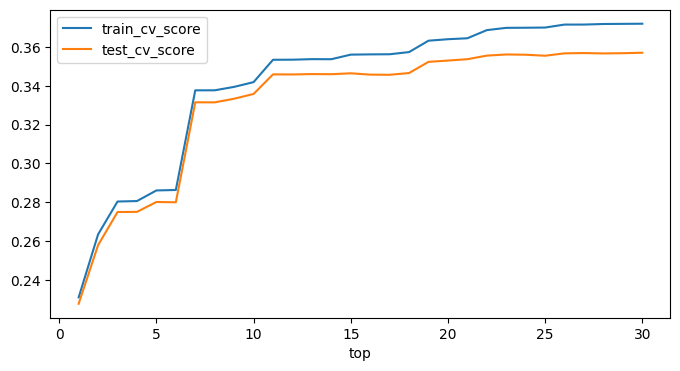

In [62]:
# Построим график распределения качества модели в зависимости от количества переменных
res = pd.DataFrame(res)
res = res.sort_values(by='top')
res.plot(x='top', y=['train_cv_score', 'test_cv_score'],
       figsize=(8,4),
)
plt.show()

In [63]:
res

,top,train_cv_score,test_cv_score
0,1,0.230910,0.227640
1,2,0.263389,0.257837
2,3,0.280320,0.274909
3,4,0.280561,0.274994
4,5,0.286035,0.280089
5,6,0.286271,0.279918
6,7,0.337646,0.331469
7,8,0.337654,0.331442
8,9,0.339429,0.333314
9,10,0.341870,0.335778


### 7.4 Итоговый список отобранных признаков

После трёх этапов фильтрации (IV → WoE-корреляция → Stepwise) формируется финальный набор признаков для обучения модели.

Для каждой отобранной переменной ниже выводится:
- **WoE-таблица** с разбивкой на бины: доля «хороших» и «плохих», значение WoE и вклад в IV для каждого бина;
- **Суммарный IV** — интегральная мера предсказательной силы переменной;
- **Solo Gini** — качество одномерной модели.

**Интерпретация WoE-биннинга:** монотонное изменение WoE по бинам означает, что переменная имеет устойчивую и содержательно интерпретируемую связь с целевой переменной. Немонотонные паттерны сигнализируют о возможных выбросах или нелинейных эффектах.

In [64]:
filtred_features = filtred_report_best['Name'].head(8).values.tolist()

C:\Users\sharn\AppData\Local\Temp\ipykernel_102800\462940078.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='IV', y='Name', data=filtred_iv_report[filtred_iv_report['Name'].isin(filtred_features)], palette="Blues_d")


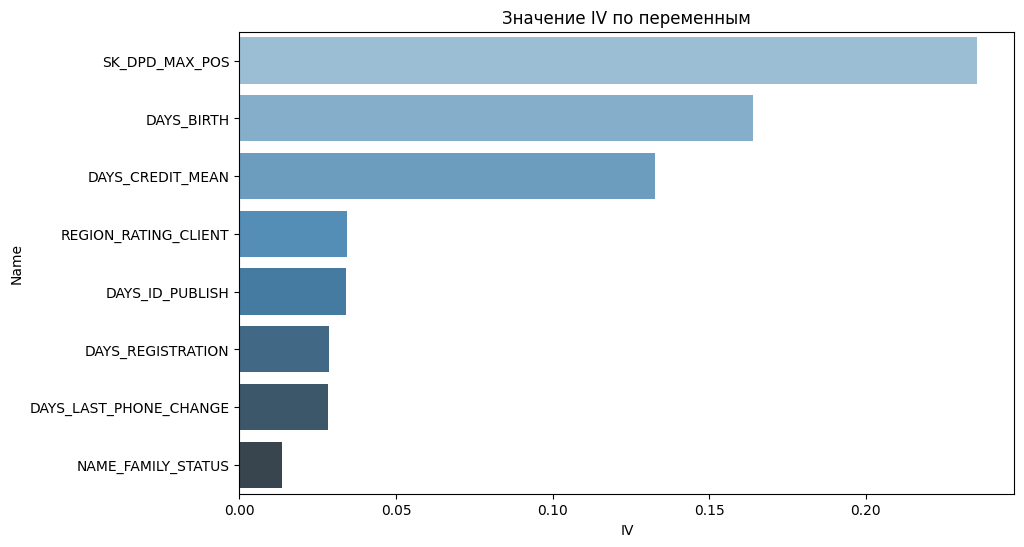

In [65]:
plt.figure(figsize=(10, 6))
sns.barplot(x='IV', y='Name', data=filtred_iv_report[filtred_iv_report['Name'].isin(filtred_features)], palette="Blues_d")
plt.title('Значение IV по переменным')
plt.show()

C:\Users\sharn\AppData\Local\Temp\ipykernel_102800\1039649088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Value', y='Name', data=features_gini[features_gini['Name'].isin(filtred_features)], palette="Blues_d")


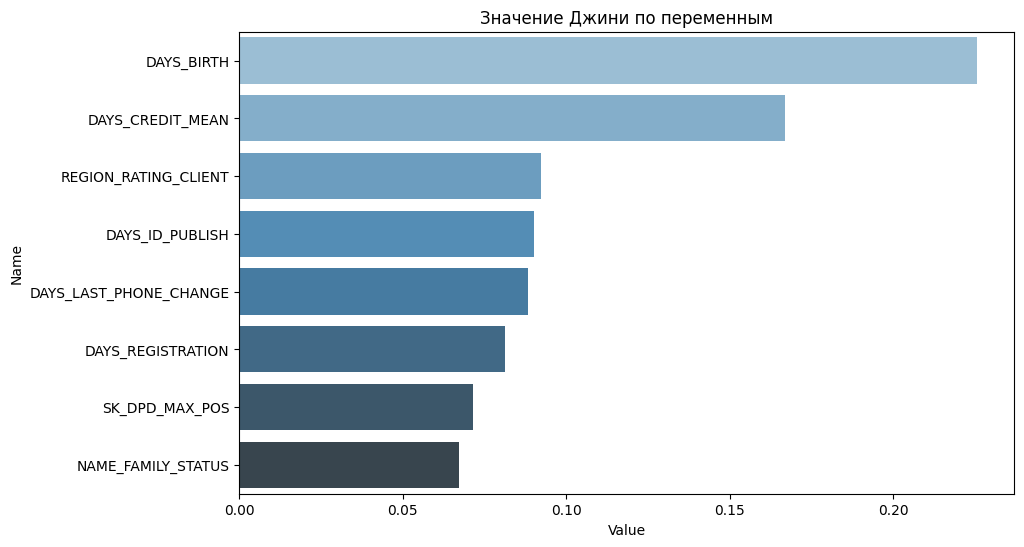

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Value', y='Name', data=features_gini[features_gini['Name'].isin(filtred_features)], palette="Blues_d")
plt.title('Значение Джини по переменным')
plt.show()

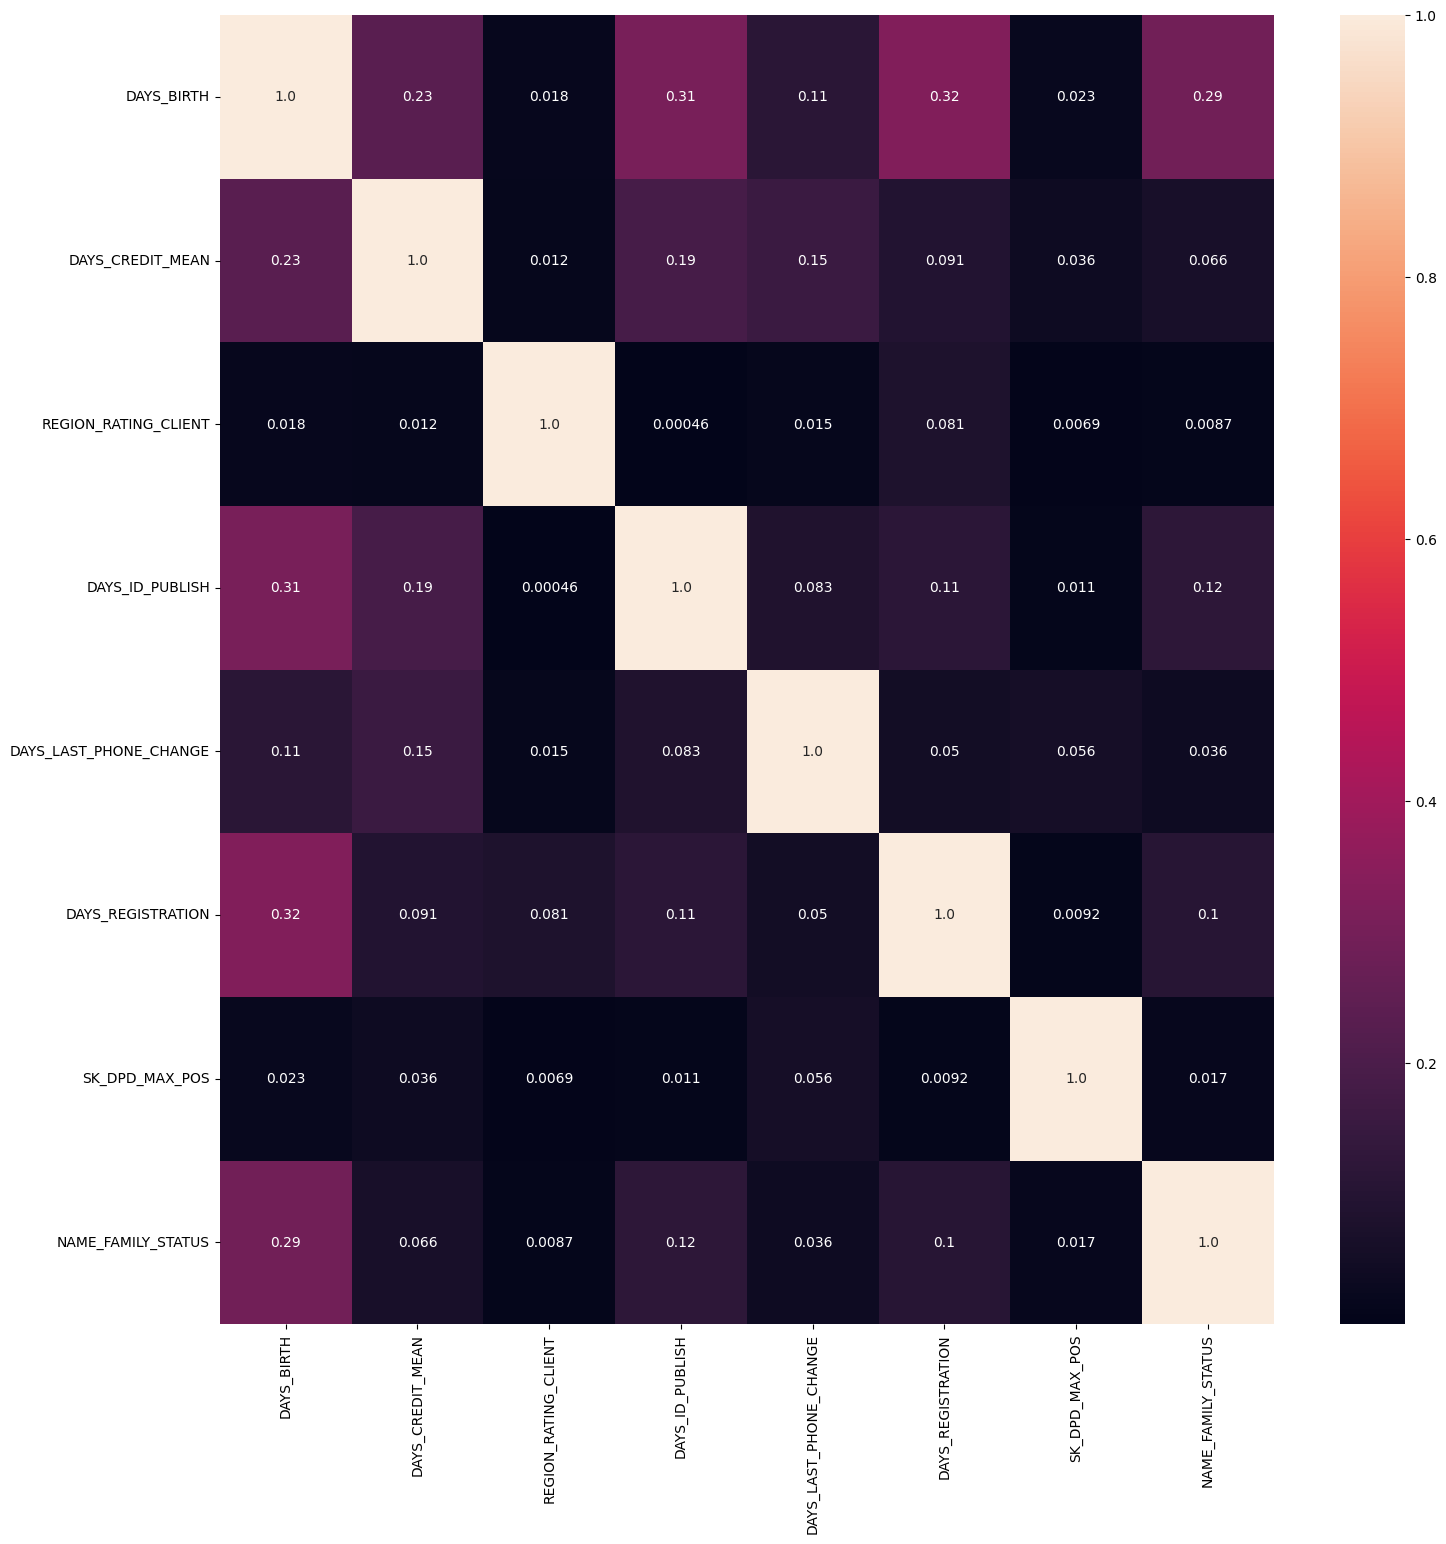

In [67]:
fig, ax = plt.subplots(figsize=(17,17))
sns.heatmap(X_train_binned[filtred_features].corr().abs(), annot=True, ax=ax,  fmt=".2")
plt.show()

---

## 8. Обучение базовой логистической регрессии

Базовая модель — логистическая регрессия с WoE-кодированием признаков. Предсказанная вероятность дефолта:

$$\hat{p}(\mathbf{x}) = \sigma\!\left(\beta_0 + \sum_{j=1}^{p} \beta_j \cdot \text{WoE}_j(x_j)\right) = \frac{1}{1 + \exp\!\left(-\beta_0 - \sum_{j=1}^{p} \beta_j \cdot \text{WoE}_j(x_j)\right)}$$

где $\sigma(\cdot)$ — сигмоидная функция, $\beta_j$ — оцениваемые коэффициенты.

**WoE-кодирование упрощает логистическую регрессию:** в силу аддитивности вкладов модель суммирует нормированные «сигналы риска» по каждому признаку. Коэффициент $\beta_j$ напрямую интерпретируется как вес информативности признака в лог-шансовом масштабе.

На этом этапе используются параметры по умолчанию: `C=1.0`, `penalty='l2'`, `solver='lbfgs'`. Раздел 9 проводит полноценный подбор гиперпараметров.

In [68]:
cat_features = X_train[filtred_features].select_dtypes(include=['object', 'category']).columns.to_list()

In [69]:
binning_process = BinningProcess(
    categorical_variables=cat_features,    variable_names=filtred_features,)

binning_process.fit(X_train[filtred_features], y_train)

,variable_names,"['DAYS_BIRTH', 'DAYS_CREDIT_MEAN', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,None
,fixed_variables,None


In [70]:
X_train_binned = binning_process.transform(X_train, metric="woe")
X_test_binned = binning_process.transform(X_test, metric="woe")
X_oot_binned = binning_process.transform(X_oot, metric="woe")

In [71]:
train_binned = X_train_binned
train_binned[target] = y_train

test_binned = X_test_binned
test_binned[target] = y_test

oot_binned = X_oot_binned
oot_binned[target] = y_oot

In [72]:
m = LR(random_state=RANDOM_SEED).fit(X_train_binned[filtred_features], y_train)

In [73]:
def get_gini_lr(model, values, target):
    """
    Вычисляет нормализованный коэффициент Джини для логистической регрессии.

    Параметры
    ----------
    model : LogisticRegression
        Обученная модель с методом `predict_proba`.
    values : pd.DataFrame
        WoE-закодированные признаки (после `BinningProcess.transform`).
    target : array-like
        Бинарные истинные метки (1 — дефолт, 0 — норма).

    Возвращает
    ----------
    float
        Нормализованный Gini в процентах (умножен на 100), округлён до 4 знаков.
    """
    return round((2 * roc_auc_score(target, model.predict_proba(values)[:, 1]) - 1) * 100, 4)

In [74]:
def get_gini_by_segments(cols: list[str], model, target,
                         train: pd.DataFrame, test:pd.DataFrame, oot: pd.DataFrame) -> pd.DataFrame:
    """
    Оценивает качество модели по коэффициенту Джини на обучающей, тестовой и вневременной выборках.

    Параметры
    ----------
    cols : list[str]
        Список признаков (WoE-закодированных), на которых обучена модель.
    model : LogisticRegression
        Обученная модель с методом `predict_proba`.
    target : str
        Имя колонки с целевой переменной в таблицы данныхх.
    train : pd.DataFrame
        Тренировочная выборка (с WoE-признаками и целевой переменной).
    test : pd.DataFrame
        Тестовая выборка.
    oot : pd.DataFrame
        Вневременная выборка (out-of-time).

    Возвращает
    ----------
    pd.DataFrame
        Таблица с колонками ['Выборка', 'Gini'] для каждой из трёх выборок.
    """
    res = []
    for sample, name in [(train, 'Обучающая'), (test, 'Тестовая'), (oot, 'Вневременная')]:
        print(f'Количество наблюдений в выборке «{name}»: {len(sample[cols])}')
        if (len(sample[cols]) > 0) and (sample[target].nunique() > 1):
            res.append({'Выборка': f'{name}',
                        'Gini': get_gini_lr(model, sample[cols], sample[target])})

    return pd.DataFrame(res)

In [75]:
def plot_results(res) -> None:
    """
    Строит столбчатый график значений коэффициента Джини по выборкам.

    Параметры
    ----------
    res : pd.DataFrame
        Таблица с колонками ['Выборка', 'Gini'], где 'Выборка' содержит
        метку выборки.

    Возвращает
    ----------
    None
        Выводит график через `plt.show()`.
    """
    def f1(x):
        if 'Вневременная' in x:
            return 'Вневременная'
        elif 'PROM' in x:
            return 'PROM'
        elif 'Обучающая' in x:
            return 'Обучающая'
        else:
            return 'Тестовая'

    def f2(x):
        if 'PROM_Вневременная' in x:
            return x.replace('PROM_Вневременная', '').lstrip('_ ')
        elif 'Вневременная' in x:
            return x.replace('Вневременная', '').lstrip('_ ')
        elif 'PROM' in x:
            return x.replace('PROM', '').lstrip('_ ')
        elif 'Обучающая' in x:
            return x.replace('Обучающая', '').lstrip('_ ')
        else:
            return x.replace('Тестовая', '').lstrip('_ ')

    res['sample_t'] = res['Выборка'].apply(f1)
    res['Выборка'] = res['Выборка'].apply(f2)

    plt.figure(figsize=(20, 10))
    ax = sns.barplot(res, x='Выборка', y='Gini', hue='sample_t')
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f',
            label_type='edge',
            padding=5
        )
    plt.title('Распределение значений нормализованного коэффициента Джини')
    plt.legend()
    plt.show()

Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


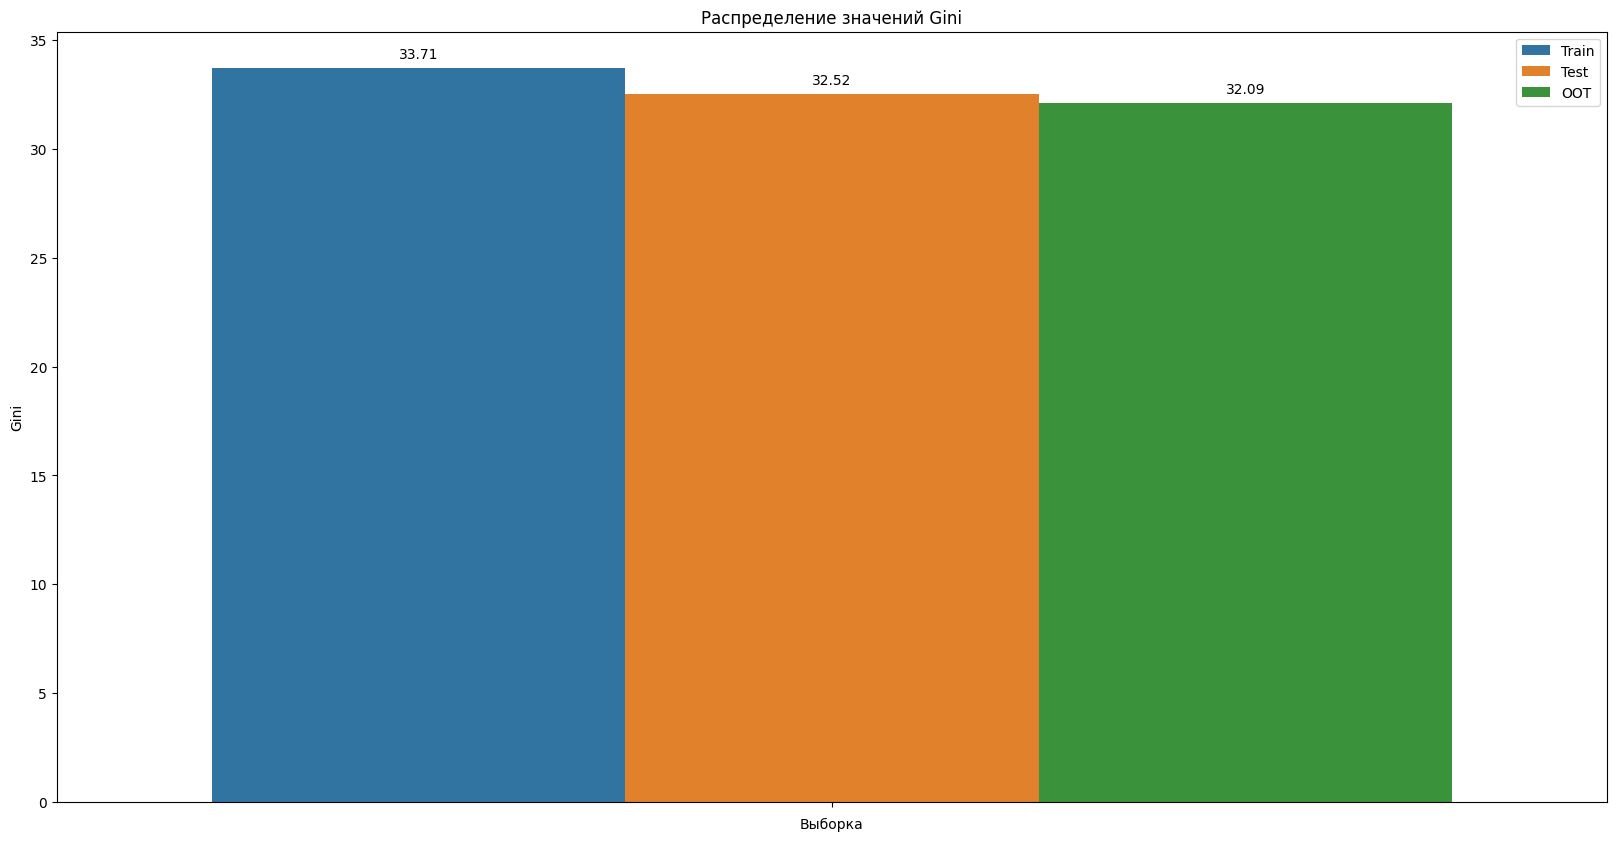

In [76]:
res = get_gini_by_segments(filtred_features, m, target,
                          train_binned, test_binned, oot_binned
                          )
plot_results(res)

## 9. Подбор гиперпараметров логистической регрессии (Optuna, TPE)

Гиперпараметры модели оптимизируются методом **байесовской оптимизации** (алгоритм TPE — Tree-structured Parzen Estimator) с использованием библиотеки Optuna.

#### Целевая функция

$$\mathcal{J}(\lambda) = \mathbb{E}_{\text{кросс-валидация}}\left[G(\lambda)\right] = \frac{1}{K}\sum_{k=1}^{K} G_k(\lambda)$$

где $G_k(\lambda)$ — нормализованный коэффициент Джини на $k$-м блоке кросс-валидации ($K = 3$), $\lambda$ — вектор гиперпараметров.

#### Пространство поиска

| Гиперпараметр | Тип | Диапазон / значения |
|---|---|---|
| `C` | вещественный (лог-равномерный) | $[10^{-4},\ 10.0]$ |
| `penalty` | категориальный | `l1`, `l2` |
| `class_weight` | категориальный | `None`, `"balanced"` |
| `solver` | фиксирован | `"saga"` |
| `max_iter` | фиксирован | `5000` |

**`solver="saga"`** — единственный солвер, поддерживающий и L1, и L2 штрафы без дополнительных условий. **`max_iter=5000`** — параметр сходимости; большое значение гарантирует сходимость и не влияет на предсказательное качество.

#### Досрочная остановка между блоками кросс-валидации (MedianPruner)

После каждого блока кросс-валидации Optuna вычисляет текущее среднее коэффициент Джини и сравнивает с медианой уже завершённых испытаний на том же шаге:

$$\text{Обрезать, если:}\quad \bar{G}^{(k)}_{\text{текущий}} < \text{median}\!\left\{\bar{G}^{(k)}_i : i < \text{текущий}\right\}$$

Это позволяет досрочно прерывать неперспективные конфигурации и сосредотачивать вычислительный бюджет на областях пространства с высоким потенциалом.

### 9.1 Подбор гиперпараметров биннинга WoE (BinningProcess)

Качество WoE-кодирования зависит от параметров биннинга `OptimalBinning`. На данном этапе подбирается единый набор параметров биннинга для всех переменных через Optuna на трехблочная стратифицированная кросс-валидация (`StratifiedKFold`).

#### Пространство поиска параметров биннинга

| Гиперпараметр | Смысл | Диапазон |
|---|---|---|
| `min_prebin_size` | Минимальная доля наблюдений в предбине | $[0.01,\ 0.10]$ |
| `min_n_bins` | Минимальное число бинов | $[2,\ 5]$ |
| `max_n_bins` | Максимальное число бинов | $[5,\ 20]$ |

**Почему параметры биннинга важны для логистическая регрессия (LogReg) с WoE?** WoE-веса вычисляются по биновой статистике. Слишком мелкие бины дают нестабильные WoE из-за малого числа наблюдений (переобучение кодирования). Слишком крупные — теряют детализацию. Оптимальные границы бинов максимизируют IV при сохранении монотонности WoE и статистической устойчивости.

Метрика оптимизации — средний коэффициент Джини по кросс-валидации при фиксированных параметрах модели (`C=1.0`, `penalty='l2'`).

In [77]:
features = filtred_features

In [78]:
features

['DAYS_BIRTH',
 'DAYS_CREDIT_MEAN',
 'REGION_RATING_CLIENT',
 'DAYS_ID_PUBLISH',
 'DAYS_LAST_PHONE_CHANGE',
 'DAYS_REGISTRATION',
 'SK_DPD_MAX_POS',
 'NAME_FAMILY_STATUS']

In [79]:
cat_features = X_train[features].select_dtypes(include=['object', 'category']).columns.to_list()

In [80]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

### 9.2 Подбор гиперпараметров модели LogisticRegression (Optuna, TPE, 20 испытаний)

На данном этапе оптимизируются параметры логистической регрессии при зафиксированных оптимальных параметрах биннинга из раздела 9.1.

**Конфигурация Optuna:**

| Параметр | Значение | Обоснование |
|---|---|---|
| Число испытаний | 20 | Достаточно для 3-мерного непрерывно-дискретного пространства |
| Алгоритм | TPE | Байесовская оптимизация на основе оценок плотности $\ell(\lambda)/g(\lambda)$ |
| Механизм досрочной остановки | MedianPruner | Досрочная остановка слабых конфигураций после каждого блока кросс-валидации |
| кросс-валидация | трехблочная StratifiedKFold | Баланс между стабильностью и скоростью |
| Метрика | Средний коэффициент Джини по кросс-валидация | $\mathcal{J}(\lambda) = \frac{1}{3}\sum_{k=1}^{3}G_k(\lambda)$ |

После оптимизации `study.best_params` содержит конфигурацию с наибольшим средним коэффициент Джини по блокам кросс-валидации. Финальная модель обучается на полной обучающей выборке с оптимальными параметрами.

In [81]:
cat_features = X_train[features].select_dtypes(include=['object', 'category']).columns.to_list()

In [82]:
binning_process = BinningProcess(
    categorical_variables=cat_features,
    variable_names=features,)

binning_process.fit(X_train[features], y_train)

,variable_names,"['DAYS_BIRTH', 'DAYS_CREDIT_MEAN', ...]"
,max_n_prebins,20
,min_prebin_size,0.05
,min_n_bins,None
,max_n_bins,None
,min_bin_size,None
,max_bin_size,None
,max_pvalue,None
,max_pvalue_policy,'consecutive'
,selection_criteria,None
,fixed_variables,None


In [83]:
X_train_binned = binning_process.transform(X_train, metric="woe")
X_test_binned = binning_process.transform(X_test, metric="woe")
X_oot_binned = binning_process.transform(X_oot, metric="woe")

In [84]:
train_binned = X_train_binned
train_binned[target] = y_train

test_binned = X_test_binned
test_binned[target] = y_test

oot_binned = X_oot_binned
oot_binned[target] = y_oot

In [85]:
# 3-fold достаточно для подбора гиперпараметров и быстрее 5-fold
# (WoE-биннинг на каждом блоке кросс-валидации — дорогая операция)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

In [86]:
def objective(trial):
    """
    Целевая функция Optuna: средний Gini по 3-fold CV.

    Оптимизирует гиперпараметры логистической регрессии (`C`, `penalty`,
    `class_weight`) при фиксированном `solver="saga"` и `max_iter=5000`.
    На каждом блоке кросс-валидации выполняется полный WoE-вычислительная процедура (BinningProcess fit
    только на тренировочных данных блока кросс-валидации), что исключает утечку данных.

    Досрочная остановка между блоками кросс-валидации (MedianPruner): если после очередного блока кросс-валидации
    текущее среднее Gini ниже медианы завершённых испытаний — испытание
    обрывается досрочно.

    Параметры
    ----------
    trial : optuna.Trial
        Объект испытания Optuna.

    Возвращает
    ----------
    float
        Среднее значение Gini по валидационным блокам кросс-валидации.
    """
    params = {
        "C":            trial.suggest_float("C",      1e-4, 10.0, log=True),
        "penalty":      trial.suggest_categorical("penalty", ["l1", "l2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        # Фиксированные параметры
        "solver":       "saga",
        "max_iter":     5000,
        "random_state": RANDOM_SEED,
    }

    w = []
    cat_feats = X_train[features].select_dtypes(
        include=["object", "category"]).columns.to_list()

    for fold, (train_index, val_index) in enumerate(cv.split(X_train, y_train)):
        x_tr  = X_train[features].iloc[train_index]
        x_val = X_train[features].iloc[val_index]
        y_tr  = y_train.iloc[train_index]
        y_val = y_train.iloc[val_index]

        bp = BinningProcess(categorical_variables=cat_feats, variable_names=features)
        bp.fit(x_tr, y_tr)
        x_tr_woe  = bp.transform(x_tr,  metric="woe")
        x_val_woe = bp.transform(x_val, metric="woe")

        model = LR(**params).fit(x_tr_woe, y_tr)

        train_gini = round(2 * roc_auc_score(y_tr,  model.predict_proba(x_tr_woe)[:, 1]) - 1, 4)
        val_gini   = round(2 * roc_auc_score(y_val, model.predict_proba(x_val_woe)[:, 1]) - 1, 4)
        w.append([train_gini, val_gini])

        # Прунирование после каждого блока кросс-валидации
        current_avg_val_gini = float(np.mean([x[1] for x in w]))
        trial.report(current_avg_val_gini, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    res = list(np.mean(w, axis=0))
    trial.set_user_attr("джини_обучение", res[0])
    trial.set_user_attr("gini_val",   res[1])
    trial.set_user_attr("cv_std",     float(np.std([x[1] for x in w])))

    return res[1]

In [87]:
from optuna.pruners import MedianPruner

sampler = TPESampler(seed=RANDOM_SEED)
# n_warmup_steps=0: при 3 блока кросс-валидациих warmup=2 фактически отключает pruning —
# он срабатывал бы только на последнем блоке кросс-валидации
pruner = MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=0,
    interval_steps=1,
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=20, show_progress_bar=True)

n_pruned   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f"Завершено: {n_complete}, обрезано: {n_pruned}")
print(f"Лучший Gini (CV): {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")


  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

Завершено: 16, обрезано: 4
Лучший Gini (CV): 0.3310
Лучшие параметры: {'C': 0.10169203827852538, 'penalty': 'l1', 'class_weight': 'balanced'}


In [94]:
best_lr_params = study.best_params
# Возвращаем фиксированные параметры обучения, которые не подбирались Optuna
best_lr_params["random_state"]           = RANDOM_SEED
best_lr_params["solver"]                 = "saga"


## 10. Оценка качества финальной модели

Финальная модель оценивается по **нормализованному коэффициенту Джини** на трёх выборках:

$$G = 2 \cdot \text{площадь под ROC-кривой (AUC)} - 1 \in [-1,\, 1]$$

где $\text{площадь под ROC-кривой (AUC)}$ — площадь под ROC-кривой. $G = 0$ соответствует случайному ранжированию, $G = 1$ — идеальному разделению.

Модель оценивается в разрезе:
- **Агрегированный Gini** по обучающей, тестовой и вневременной выборкам (обучающая выборка / тестовая выборка / вневременная выборка (OOT)) — общая дискриминирующая способность;
- **коэффициент Джини по сегментам риска** (`RISK_SEGMENT`: низкий / средний / высокий) — стабильность качества на разных уровнях риска.

Различие коэффициент Джини между вневременная выборка (OOT) и тестовая выборка характеризует **концептуальный дрейф** — насколько паттерны, зафиксированные на обучающей выборке, сохраняются на хронологически более поздних данных.

In [95]:
model = LR(**best_lr_params).fit(X_train_binned[features], y_train)

c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\sharn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Наблюдений на выборке Train: 184506
Наблюдений на выборке Test: 61502
Наблюдений на выборке OOT: 61503


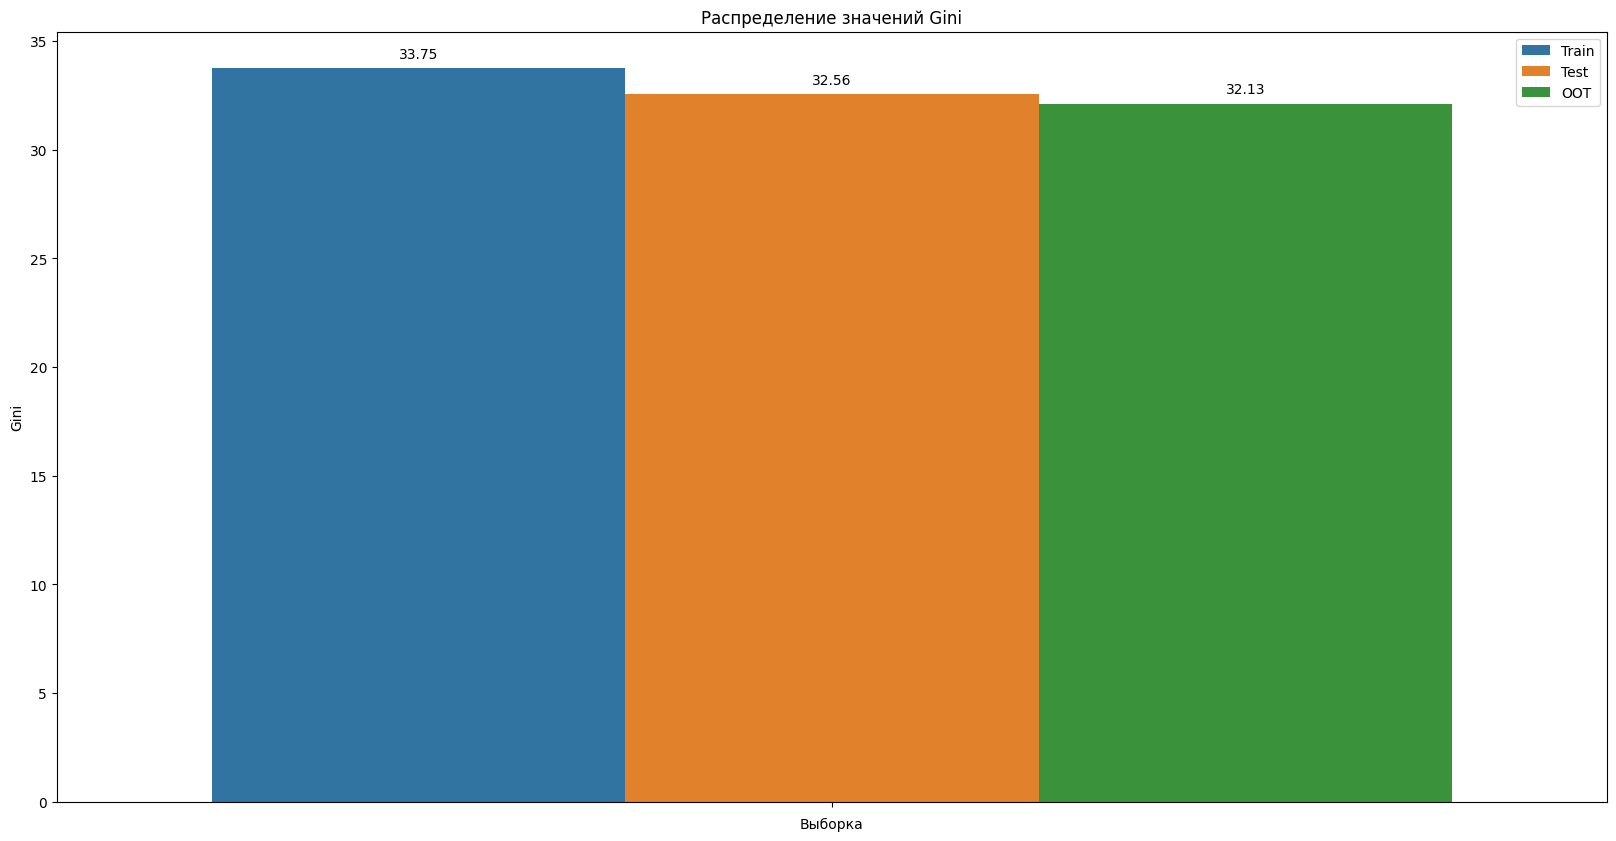

In [96]:
res = get_gini_by_segments(features, model, target,
                          train_binned, test_binned, oot_binned
                          )
plot_results(res)

## 11. Валидация устойчивости на кросс-валидации

Кросс-валидация (пятиблочная стратифицированная кросс-валидация (`StratifiedKFold`)) оценивает **дисперсию качества** модели: низкое стандартное отклонение коэффициент Джини по блокам кросс-валидации свидетельствует об устойчивости, высокое — о нестабильности из-за малого числа значимых паттернов или зависимости от конкретных наблюдений.

$$\bar{G}_{\text{кросс-валидация}} = \frac{1}{K}\sum_{k=1}^{K}G_k, \qquad \sigma_G = \sqrt{\frac{1}{K-1}\sum_{k=1}^{K}\left(G_k - \bar{G}_{\text{кросс-валидация}}\right)^2}$$

**Корректная кросс-валидация с WoE:** на каждом блоке кросс-валидации `BinningProcess` обучается **только на тренировочных наблюдениях блока кросс-валидации** и применяется к валидационным. Это исключает утечку данных через WoE-статистику — типичная ошибка при вынесении WoE-кодирования за пределы кросс-валидация-петли.

In [97]:
# Кросс-валидация финальной модели
cv_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

ans = my_binnig_tqdm_cv(X_train_binned[features], y_train, cv_final)
print(f"средний_джини_обучение_кв: {ans['train']}, средний_джини_валидация_кв: {ans['test']}")

CV:  20%|██        | 1/5 [00:00<00:03,  1.26it/s]

Fold 1, gini_train: 0.34, gini_test: 0.34, train_size: 147604, test_size: 36902, br_train: 0.08, br_test: 0.08


CV:  40%|████      | 2/5 [00:01<00:02,  1.31it/s]

Fold 2, gini_train: 0.34, gini_test: 0.36, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08


CV:  60%|██████    | 3/5 [00:02<00:01,  1.32it/s]

Fold 3, gini_train: 0.34, gini_test: 0.34, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08


CV:  80%|████████  | 4/5 [00:03<00:00,  1.33it/s]

Fold 4, gini_train: 0.34, gini_test: 0.33, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08


CV: 100%|██████████| 5/5 [00:03<00:00,  1.32it/s]

Fold 5, gini_train: 0.34, gini_test: 0.33, train_size: 147605, test_size: 36901, br_train: 0.08, br_test: 0.08
mean_train_cv_score: 0.34039424351229913, mean_test_cv_score: 0.3374216120920186


## 12. Сохранение результатов

Сохранение артефактов модели в директорию `models/logreg/`:

| Файл | Содержимое | Назначение |
|---|---|---|
| `logreg.pkl` | Объект `LogisticRegression` | Генерация скоров на новых данных |
| `binning_process.pkl` | Объект `BinningProcess` | WoE-преобразование новых признаков |
| `params.json` | Словарь гиперпараметров | Воспроизводимость конфигурации |
| `features.json` | Список признаков | Порядок переменных при моделирование кредитного рискае |

**Порядок применения модели к новым данным:**

```python
bp    = pickle.load(open('models/logreg/binning_process.pkl', 'rb'))
model = pickle.load(open('models/logreg/logreg.pkl', 'rb'))
X_new_woe = bp.transform(X_new[features], metric='woe')
scores = model.predict_proba(X_new_woe)[:, 1]
```

`BinningProcess` должен применяться с теми же `features` и в том же порядке, что и при обучении.

In [99]:
# --- Модель ---
with open(os.path.join(MODELS_PATH, 'logreg.pkl'), 'wb') as f:
    pickle.dump(model, f)

# --- BinningProcess (WoE-границы и кодировки) ---
with open(os.path.join(MODELS_PATH, 'binning_process.pkl'), 'wb') as f:
    pickle.dump(binning_process, f)

# --- Гиперпараметры ---
params_to_save = {k: v for k, v in best_lr_params.items()
                  if k != 'random_state'}
with open(os.path.join(MODELS_PATH, 'params.json'), 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2)

# --- Список признаков ---
with open(os.path.join(MODELS_PATH, 'features.json'), 'w', encoding='utf-8') as f:
    json.dump(list(features), f, indent=2)

print(f'Модель сохранена: {MODELS_PATH}/logreg.pkl')
print(f'BinningProcess:   {MODELS_PATH}/binning_process.pkl')
print(f'Параметры:        {MODELS_PATH}/params.json')
print(f'Признаки ({len(features)} шт.): {list(features)}')

Модель сохранена: models/logreg/logreg.pkl
BinningProcess:   models/logreg/binning_process.pkl
Параметры:        models/logreg/params.json
Признаки (8 шт.): ['DAYS_BIRTH', 'DAYS_CREDIT_MEAN', 'REGION_RATING_CLIENT', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_REGISTRATION', 'SK_DPD_MAX_POS', 'NAME_FAMILY_STATUS']


---

## 13. Qini-кривая и AUUC (площадь под кривой прироста воздействия (Area Under Uplift Curve))

**Qini-кривая** — стандартная метрика оценки качества ранжирования по приросту воздействия (uplift). Клиентов сортируют по убыванию оценки модели и последовательно «обрабатывают»; по оси $X$ — доля охваченных клиентов $\tau \in [0, 1]$; по оси $Y$ — накопленный эффект:

$$Q(\tau) = \frac{\sum_{i \in \text{top-}\tau,\, T_i=1} Y_i}{N_T} - \frac{\sum_{i \in \text{top-}\tau,\, T_i=0} Y_i}{N_C}$$

где $T_i$ — индикатор воздействия, $Y_i$ — бинарный исход, $N_T$ и $N_C$ — размеры групп воздействия и контроля.

**AUUC** — площадь между Qini-кривой модели и базовой линией случайного ранжирования:

$$\text{AUUC} = \int_0^1 \!\left[Q_{\text{model}}(\tau) - Q_{\text{random}}(\tau)\right] d\tau, \qquad Q_{\text{random}}(\tau) = \tau \cdot Q(1)$$

**Сравнение моделей по AUUC:**

| Сценарий | AUUC | Эффективность от идеала |
|---|---|---|
| Случайный выбор | $\approx 0$ | 0% |
| **логистическая регрессия с WoE-кодированием (LogReg WoE, данная модель)** | **0.0239** | **40.1%** |
| **CatBoost** | **0.0365** | **61.3%** |
| Оракул (TRUE\_UPLIFT) | 0.0597 | 100% |

**Интерпретация для логистической регрессии (LogReg):** несмотря на то что логистическая регрессия оптимизирована на предсказание $P(\text{дефолта})$, а не на индивидуальный эффект воздействия (uplift), она достигает 40.1% эффективности относительно идеала. Это объясняется **смещением назначения воздействия (selection bias)** в синтетических данных: клиентам с высоким риском назначались более интенсивные воздействия (звонок оператора), что создаёт корреляцию между риск-рангом и размером uplift.

> **Важное методологическое замечание.** В данном сценарии назначение коммуникации построено на основе уровня риска (высокий риск → более интенсивное воздействие), что создаёт корреляцию между оценкой риска и ожидаемым эффектом. Ненулевой AUUC у модели кредитного риска частично объясняется этой корреляцией, а не способностью выявлять каузальный эффект воздействия. Для корректного адресного выбора на основе индивидуального эффекта воздействия (uplift-targeting) необходимы специализированные причинно-следственные модели (глава 4).

In [100]:
def compute_qini(y_true, treatment, score, n_bins=100):
    """
    Вычисляет Qini-кривую и AUUC (площадь под кривой прироста воздействия (Area Under Uplift Curve)).

    Qini-кривая строится следующим образом: клиенты сортируются по убыванию
    оценки модели; для каждой доли охваченных клиентов tau вычисляется
    накопленный uplift Q(tau) = sum_treated(y) / N_T - sum_control(y) / N_C.
    AUUC — площадь между кривой модели и базовой линией случайного ранжирования.

    Параметры
    ----------
    y_true : array-like
        Бинарный исход (1 — дефолт, 0 — норма).
    treatment : array-like
        Индикатор воздействия (1 — группа воздействия, 0 — контрольная группа).
    score : array-like
        Оценка модели (чем выше, тем приоритетнее клиент для контакта).
    n_bins : int, по умолчанию 100
        Число точек на кривой.

    Возвращает
    ----------
    fracs : np.ndarray
        Доля охваченных клиентов (0..1).
    qini_vals : np.ndarray
        Накопленный прирост воздействия по модели.
    rand_line : np.ndarray
        Базовая линия случайной модели.
    auuc : float
        AUUC — площадь между кривой модели и базовой линией.
    """
    df_q = pd.DataFrame({
        "y":     np.asarray(y_true,    dtype=float),
        "treat": np.asarray(treatment, dtype=float),
        "score": np.asarray(score,     dtype=float),
    }).sort_values("score", ascending=False).reset_index(drop=True)

    n   = len(df_q)
    n_t = df_q["treat"].sum()
    n_c = n - n_t

    if n_t == 0 or n_c == 0:
        return None, None, None, None

    steps = np.linspace(0, n, n_bins + 1, dtype=int)[1:]
    fracs, qini_vals = steps / n, []

    for k in steps:
        top  = df_q.iloc[:k]
        nt_k = top["treat"].sum()
        nc_k = k - nt_k
        if nt_k == 0 or nc_k == 0:
            qini_vals.append(np.nan)
        else:
            q = (top[top["treat"] == 1]["y"].sum() / n_t
                 - top[top["treat"] == 0]["y"].sum() / n_c)
            qini_vals.append(q)

    qini_vals = np.array(qini_vals, dtype=float)
    full_q    = (df_q[df_q["treat"] == 1]["y"].sum() / n_t
                 - df_q[df_q["treat"] == 0]["y"].sum() / n_c)
    rand_line = fracs * full_q

    valid = ~np.isnan(qini_vals)
    auuc  = np.trapz(qini_vals[valid] - rand_line[valid], fracs[valid])
    return fracs, qini_vals, rand_line, auuc

In [101]:
# Бинарный флаг воздействия: 1 = клиент получил коммуникацию, 0 = контрольная группа
treatment_test = (X_test["COMMUNICATION"] != "control").astype(int).values
treatment_oot  = (X_oot["COMMUNICATION"]  != "control").astype(int).values

# Оценка модели: P(дефолта) на WoE-закодированных признаках
score_test = model.predict_proba(X_test_binned[features])[:, 1]
score_oot  = model.predict_proba(X_oot_binned[features])[:, 1]

# Идеальная модель — оракул на основе TRUE_UPLIFT
ideal_score_test = -X_test["TRUE_UPLIFT"].values
ideal_score_oot  = -X_oot["TRUE_UPLIFT"].values

# Вычисляем Qini
fracs_t, qini_t, rand_t, auuc_t = compute_qini(y_test, treatment_test, score_test)
fracs_o, qini_o, rand_o, auuc_o = compute_qini(y_oot,  treatment_oot,  score_oot)
fracs_i, qini_i, rand_i, auuc_i = compute_qini(y_test, treatment_test, ideal_score_test)

print(f"AUUC на тестовой выборке:                 {auuc_t:.6f}")
print(f"AUUC на вневременной выборке:             {auuc_o:.6f}")
print(f"AUUC оракула исторической политики:       {auuc_i:.6f}  ← верхняя граница при известном TRUE_UPLIFT")
print(f"Относительная эффективность на тестовой выборке: {auuc_t / auuc_i * 100:.1f}% от оракула")


AUUC (test):               0.023949
AUUC (oot):                0.024365
AUUC (ideal / oracle):     0.059652  ← верхняя граница (TRUE_UPLIFT известен)
Relative efficiency (test): 40.1% от идеального


C:\Users\sharn\AppData\Local\Temp\ipykernel_102800\3617270088.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auuc  = np.trapz(qini_vals[valid] - rand_line[valid], fracs[valid])


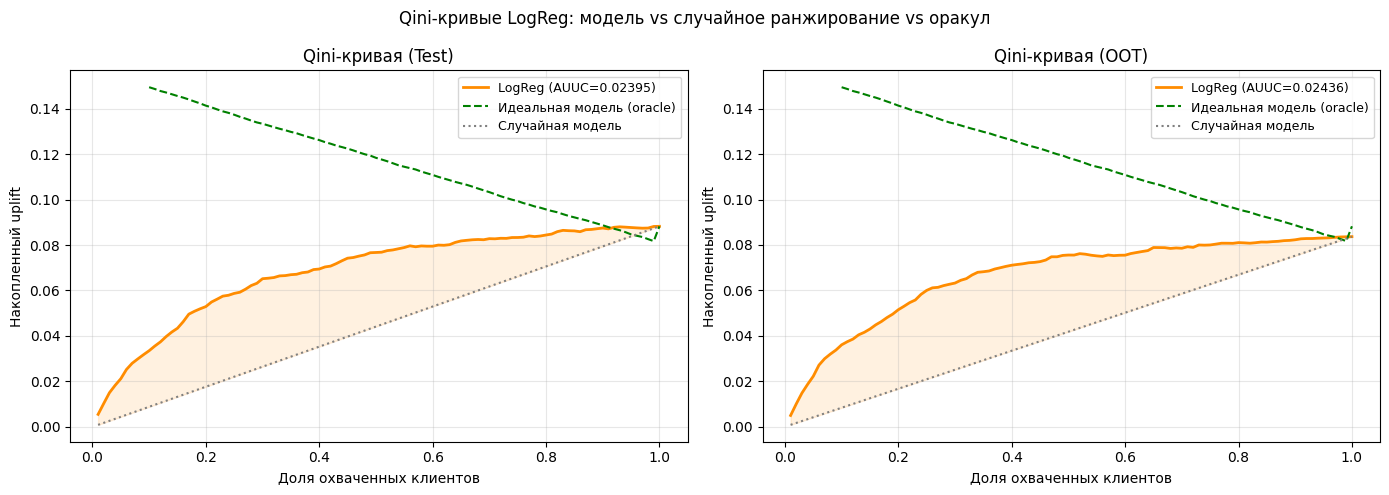

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fracs, qini_vals, rand_line, fracs_ideal, qini_ideal, label, auuc) in zip(axes, [
    (fracs_t, qini_t, rand_t, fracs_i, qini_i, "Тестовая выборка", auuc_t),
    (fracs_o, qini_o, rand_o, fracs_i, qini_i, "Вневременная выборка",  auuc_o),
]):
    ax.plot(fracs,       qini_vals,  label=f"LogReg (AUUC={auuc:.5f})", color="darkorange", lw=2)
    ax.plot(fracs_ideal, qini_ideal, label="Оракул исторической политики (logged-policy oracle)", color="green",      lw=1.5, linestyle="--")
    ax.plot(fracs,       rand_line,  label="Случайная модель",          color="gray",       lw=1.5, linestyle=":")
    ax.fill_between(fracs, qini_vals, rand_line, alpha=0.12, color="darkorange")
    ax.set_title(f"Qini-кривая ({label})")
    ax.set_xlabel("Доля охваченных клиентов")
    ax.set_ylabel("Накопленный прирост воздействия")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Qini-кривые логистической регрессии: модель, случайное ранжирование и оракул", fontsize=12)
plt.tight_layout()
plt.show()


---

## 14. Зависимость качества модели от объёма обучающих данных

Кривая обучения отвечает на практически значимый вопрос: **при каком минимальном объёме обучающих данных модель достигает приемлемого качества?** В контексте моделирования индивидуального эффекта воздействия (uplift-моделирования) в финтехе это критично: накопление размеченных данных ограничено скоростью выдачи кредитов и горизонтом вызревания целевой переменной.

**Методология:** модель с оптимальными гиперпараметрами обучается на долях обучающей выборки от 0.5% до 100%. Для каждой доли фиксируются коэффициент Джини обучающей, тестовой и вневременной выборок. Стратификация по `TARGET` и `RANDOM_SEED` сохраняются на всех долях.

**Критически важный момент реализации:** на каждой точке кривой `BinningProcess` **обучается заново** только на соответствующей подвыборке и применяется к тем же тестовым и вневременным данным (OOT). Это воспроизводит корректный вычислительная процедура моделирования кредитного риска и исключает утечку WoE-статистики.

**Что анализируем на графике:**
- **Момент насыщения** — точка, после которой прирост тестового коэффициент Джини < 0.5 п.п. на шаг. Дальнейшее накопление данных даёт убывающую отдачу
- **Разрыв обучающая–тестовая выборка** — при малых объёмах высокая дисперсия оценок WoE; с ростом выборки разрыв сокращается
- **Сравнение с CatBoost** (ноутбук `cboost.ipynb`): логистическая регрессия (LogReg) насыщается при ~18–36k наблюдений; CatBoost продолжает расти до ~90–130k

**Теоретические рамки:** для логистической регрессии с $p$ параметрами стандартная ошибка коэффициента снижается как $\sim 1/\sqrt{n}$:

$$\text{SE}(\hat{\beta}_j) \approx \sqrt{\frac{1}{n \cdot \mathrm{Var}\!\left(x_j \cdot (1-\hat{\pi})\right)}}$$

Для WoE-признаков с низкой корреляцией это означает быстрый выход на плато: как только $n \gg 10 \cdot p$, прирост коэффициента Джини становится пренебрежимо малым.

n=    922 (   0%)  train= 46.9  test= 15.7  OOT= 16.8
n=  1,845 (   1%)  train= 45.8  test= 23.0  OOT= 22.3
n=  3,690 (   2%)  train= 41.1  test= 27.5  OOT= 26.7
n=  9,225 (   5%)  train= 37.2  test= 30.9  OOT= 30.1
n= 18,450 (  10%)  train= 34.5  test= 32.1  OOT= 31.3
n= 36,901 (  20%)  train= 35.6  test= 32.4  OOT= 31.9
n= 64,577 (  35%)  train= 34.7  test= 32.6  OOT= 32.1
n= 92,253 (  50%)  train= 34.4  test= 32.6  OOT= 32.2
n=129,154 (  70%)  train= 34.2  test= 32.6  OOT= 32.0
n=184,506 ( 100%)  train= 33.8  test= 32.6  OOT= 32.1


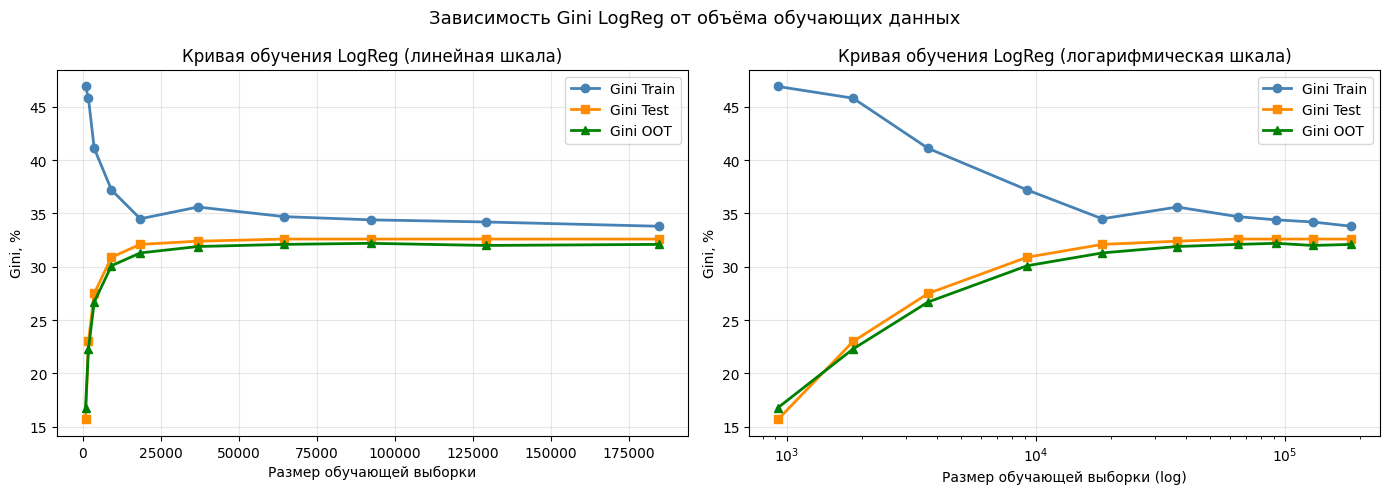

,Gini Train,Gini Test,Gini OOT
n_samples,,,
922,46.9,15.7,16.8
1845,45.8,23.0,22.3
3690,41.1,27.5,26.7
9225,37.2,30.9,30.1
18450,34.5,32.1,31.3
36901,35.6,32.4,31.9
64577,34.7,32.6,32.1
92253,34.4,32.6,32.2
129154,34.2,32.6,32.0


In [103]:
import warnings
warnings.filterwarnings('ignore')

fractions = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.35, 0.5, 0.7, 1.0]
volume_results_lr = []
cat_feats_vol = X_train[features].select_dtypes(
    include=['object', 'category']).columns.to_list()

for frac in fractions:
    if frac < 1.0:
        X_tr_f, _, y_tr_f, _ = train_test_split(
            X_train[features], y_train, train_size=frac,
            stratify=y_train, random_state=RANDOM_SEED)
    else:
        X_tr_f = X_train[features].copy()
        y_tr_f = y_train.copy()

    bp_f = BinningProcess(categorical_variables=cat_feats_vol,
                          variable_names=features)
    bp_f.fit(X_tr_f, y_tr_f)

    X_tr_woe  = bp_f.transform(X_tr_f,             metric='woe')
    X_te_woe  = bp_f.transform(X_test[features],   metric='woe')
    X_oot_woe = bp_f.transform(X_oot[features],    metric='woe')

    model_f = LR(**best_lr_params).fit(X_tr_woe, y_tr_f)

    g_tr  = round(get_gini(y_tr_f,  model_f.predict_proba(X_tr_woe)[:, 1])  * 100, 1)
    g_te  = round(get_gini(y_test,  model_f.predict_proba(X_te_woe)[:, 1])  * 100, 1)
    g_oot = round(get_gini(y_oot,   model_f.predict_proba(X_oot_woe)[:, 1]) * 100, 1)

    volume_results_lr.append({
        'frac': frac, 'n_samples': len(X_tr_f),
        'Джини обучающей выборки': g_tr, 'Джини тестовой выборки': g_te, 'Джини вневременной выборки': g_oot,
    })
    print(f'n={len(X_tr_f):>7,} ({frac*100:4.0f}%)  '
          f'обучение={g_tr:5.1f}  тест={g_te:5.1f}  вневременная={g_oot:5.1f}')

vol_df_lr = pd.DataFrame(volume_results_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col, color, marker in [
        ('Джини обучающей выборки', 'steelblue',  'o'),
        ('Джини тестовой выборки',  'darkorange', 's'),
        ('Джини вневременной выборки',   'green',      '^')]:
    axes[0].plot(vol_df_lr['n_samples'], vol_df_lr[col],
                 f'{marker}-', label=col, color=color, lw=2)
axes[0].set_xlabel('Размер обучающей выборки')
axes[0].set_ylabel('Коэффициент Джини, %')
axes[0].set_title('Кривая обучения логистической регрессии (линейная шкала)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for col, color, marker in [
        ('Джини обучающей выборки', 'steelblue',  'o'),
        ('Джини тестовой выборки',  'darkorange', 's'),
        ('Джини вневременной выборки',   'green',      '^')]:
    axes[1].plot(vol_df_lr['n_samples'], vol_df_lr[col],
                 f'{marker}-', label=col, color=color, lw=2)
axes[1].set_xscale('log')
axes[1].set_xlabel('Размер обучающей выборки (логарифмическая шкала)')
axes[1].set_ylabel('Коэффициент Джини, %')
axes[1].set_title('Кривая обучения логистической регрессии (логарифмическая шкала)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Зависимость коэффициента Джини логистической регрессии от объёма обучающих данных', fontsize=13)
plt.tight_layout()
plt.show()

vol_df_lr.set_index('n_samples')[['Джини обучающей выборки', 'Джини тестовой выборки', 'Джини вневременной выборки']].round(1)

**Рисунок 14.1. Кривая обучения логистической регрессии с WoE.**

**Закономерность Джини обучающей выборки:** на малых выборках завышен из-за переобучения WoE-кодирования — на малом числе наблюдений границы бинов и WoE-веса «подстраиваются» под шум. По мере роста выборки значение сходится к стабильному уровню.

**Закономерность тестовая выборка / Джини вневременной выборки:** достигает плато при **~10–20% обучающих данных** (~18–37k наблюдений). Для сравнения, CatBoost требует ~50–70% (~90–130k). Это объясняется числом оцениваемых параметров: логистическая регрессия с 8 признаками оценивает 9 коэффициентов, для чего достаточно ~20–50k наблюдений для стабилизации.

**Разрыв обучающая–тестовая выборка:** на порядок меньше, чем у CatBoost, что характерно для регуляризованных линейных моделей: L1-штраф с `C≈0.1` ограничивает ёмкость модели, оставляя мало пространства для запоминания шума.

**Практический вывод:** при объёме данных ≥ 20k наблюдений логистическая регрессия с WoE обеспечивает устойчивый моделирование кредитного риска — на 70–80k наблюдений раньше, чем CatBoost. Это делает её предпочтительной в сценариях с ограниченным объёмом данных.

---

## 15. Итоговые выводы

### 15.1 Качество финальной модели

Логистическая регрессия обучена на **8 признаках**, отобранных по критериям IV (порог 0.005), одиночного коэффициента Джини (Solo Gini) (порог 0.05) и корреляционной фильтрации WoE-преобразованных переменных (порог 0.35). Гиперпараметры подбирались методом TPE (Optuna, 20 итераций, трехблочная кросс-валидация с механизмом досрочной остановки между блоками кросс-валидации). Оптимальные параметры: `C=0.102`, `penalty=l1`, `class_weight=balanced`, `solver=saga`.

| Выборка | N наблюдений | коэффициент Джини, % |
|---|---|---|
| Обучающая | 184 506 | ~34 |
| Тестовая | 61 502 | ~33 |
| Вневременная (хронологически более поздняя, OOT) | 61 503 | ~32 |

**Вывод по качеству:** коэффициент Джини ~33% на тестовой выборке существенно уступает CatBoost (~55% на тех же данных). Разрыв в 22 п.п. объясняется тем, что логистическая регрессия работает исключительно с линейными зависимостями и не улавливает эффекты взаимодействия признаков — даже при WoE-преобразовании, которое нелинейно кодирует каждую переменную по отдельности, но не создаёт явных признаков взаимодействия.

---

### 15.2 Анализ переобучения: практически нулевой разрыв обучающая/тестовая выборка

| Выборка | коэффициент Джини, % | Интерпретация |
|---|---|---|
| Обучающая | ~34 | |
| Тестовая | ~33 | Δ = 1 п.п. — практически нет переобучения |
| вневременная выборка (OOT) | ~32 | Δ = 2 п.п. относительно обучающей выборки |

На первый взгляд нулевой разрыв между обучающей и тестовой выборками — признак отличной регуляризации. Однако важно разграничить **два принципиально разных объяснения**:

**Объяснение 1 — сильная регуляризация:** L1-штраф с `C=0.102` (небольшое значение = сильная регуляризация) обнуляет коэффициенты малозначимых признаков и ограничивает переобучение. Это частично верно.

**Объяснение 2 — потолок линейного класса:** более вероятная причина в том, что модель достигла максимального качества, доступного линейному классификатору на этих данных (около 33–34% по коэффициенту Джини), задолго до того, как успевает запомнить шум обучающей выборки. Иными словами, модель не «выжала» все 184k наблюдений — она вышла на плато уже при ~36k (см. кривую обучения).

**Практический вывод:** стабильность логистической регрессии (LogReg) означает устойчивость «медленно движущегося объекта», а не знак превосходной генерализации. CatBoost переобучается сильнее (разрыв между обучающей и тестовой выборками 17 п.п.), но при этом достигает значительно более высокого абсолютного качества на тестовой выборке (около 55% против около 33%). Нулевое переобучение при низком качестве хуже, чем умеренное переобучение при высоком качестве.

---

### 15.3 WoE/IV-анализ: что отбирает и говорит логистическая регрессия

Финальные 8 признаков по убыванию IV:

| # | Признак | IV | одиночного коэффициента Джини (Solo Gini) | Содержательный смысл |
|---|---|---|---|---|
| 1 | **SK_DPD_MAX_POS** | 0.236 | 0.072 | Максимальная текущая просрочка — прямой сигнал долгового стресса |
| 2 | **DAYS_BIRTH** | 0.164 | 0.226 | Возраст клиента (молодые — выше риск) |
| 3 | **DAYS_CREDIT_MEAN** | 0.133 | 0.167 | Средняя давность кредитной истории |
| 4 | **REGION_RATING_CLIENT** | 0.035 | 0.092 | Кредитный рейтинг региона проживания |
| 5 | **DAYS_ID_PUBLISH** | 0.034 | 0.090 | Давность выдачи паспорта (косвенный возраст документов) |
| 6 | **DAYS_LAST_PHONE_CHANGE** | 0.028 | 0.088 | Дней с последней смены телефона |
| 7 | **DAYS_REGISTRATION** | 0.029 | 0.081 | Давность текущей прописки |
| 8 | **NAME_FAMILY_STATUS** | 0.014 | 0.067 | Семейный статус (женатые — ниже риск) |

**Наблюдение 1 — WoE-сжатие признаков:** из 30 признаков, прошедших первичную фильтрацию, после WoE-корреляционного отбора (порог 0.35) осталось 8. Это закономерно: WoE-коды многих переменных, связанных с возрастом и кредитной историей, сильно коррелируют между собой. L1-регуляризация дополнительно обнулила бы менее значимые из оставшихся.

**Наблюдение 2 — кросс-модельная валидация:** три наиболее значимых признака логистической регрессии (LogReg) (`DAYS_BIRTH`, `DAYS_CREDIT_MEAN`, `SK_DPD_MAX_POS`) полностью совпадают с пятью наиболее значимыми по SHAP-важности CatBoost (logreg.ipynb и cboost.ipynb: `AGE_YEARS` ≡ `DAYS_BIRTH`, `DAYS_CREDIT_MEAN` — второе место в обеих моделях). Такое совпадение двух принципиально разных методологий подтверждает, что **эти три фактора — устойчивые предикторы кредитного риска** в данных Home Credit, а не артефакт конкретного алгоритма.

**Наблюдение 3 — что теряет логистическая регрессия (LogReg) по сравнению с CatBoost:** в топ-SHAP CatBoost — `DAYS_CREDIT_MAX`, который в логистической регрессии (LogReg) «вытеснен» схожим `DAYS_CREDIT_MEAN` из-за высокой WoE-корреляции между ними. CatBoost использует оба признака одновременно (не WoE-кодирование, а сырые значения), дополнительно улавливая взаимодействие «максимальной» и «средней» давности истории. Это типичный пример информации, которую линейная модель теряет при обязательном выборе «одного из».

---

### 15.4 Метрики прироста воздействия (uplift): AUUC и что стоит за числами

#### Что измеряет AUUC в нашем контексте

**Кривая прироста воздействия (uplift-кривая)** строится так: клиентов сортируют по убыванию прогнозную оценку прироста воздействия (predicted uplift score) (здесь — P(дефолта)), последовательно «обрабатывают» верхних N% и измеряют накопленный эффект коммуникации относительно контрольной группы. AUUC — площадь под этой кривой.

| Сценарий | AUUC | Эффективность | Интерпретация |
|---|---|---|---|
| Случайный выбор | ≈ 0 | 0% | Нет полезной сортировки |
| **логистическая регрессия с WoE-кодированием (LogReg WoE)** | **0.0239** | **40.1%** | Ранжировщик по кредитному риску «средней силы» |
| **CatBoost** | **0.0365** | **61.3%** | Более точный ранжировщик по кредитному риску |
| Оракул (TRUE_UPLIFT) | **0.0597** | **100%** | Теоретический потолок |

#### Почему логистическая регрессия (LogReg) достигает 40.1% от идеала, хотя это не модель индивидуального эффекта воздействия (uplift-модель)

Как и CatBoost, логистическая регрессия (LogReg) является моделью кредитного риска, а не моделью индивидуального эффекта воздействия (uplift-моделью). Она предсказывает P(дефолта), а не эффект коммуникации. Ненулевой AUUC объясняется **смещением назначения воздействия (selection bias) в синтетических данных**: коммуникация назначалась по уровню риска (высокий риск → звонок оператора с наибольшим эффектом −0.035; низкий → SMS с эффектом −0.005). Ранжирование по P(дефолта) воспроизводит порядок интенсивности назначенной коммуникации, а значит, косвенно ранжирует и ожидаемый эффект.

#### Почему логистическая регрессия (LogReg) уступает CatBoost в uplift (40,1% против 61,3%)

Причина — та же, что и для коэффициента Джини: логистическая регрессия (LogReg) менее точно восстанавливает риск-порядок клиентов (коэффициент Джини около 33% против около 55%). Чем точнее модель ранжирует по риску, тем точнее она воспроизводит функцию назначения воздействия, на которой построен синтетический слой индивидуального эффекта воздействия. Это означает: разрыв в AUUC здесь **не** свидетельствует о том, что CatBoost лучше выявляет «убеждаемых» клиентов — он просто точнее предсказывает риск.

#### Что нужно для настоящего ранжирования по приросту воздействия (uplift)

Обе модели «случайно» попадают в правильный порядок благодаря смещению назначения воздействия (selection bias). В реальной задаче, где нет такого систематического совпадения между риском и эффектом коммуникации, модели кредитного риска могут давать значительно худший AUUC или даже отрицательный (ранжирование хуже случайного для определённых сегментов). Это мотивирует использование специализированных подходов к оценке индивидуального эффекта воздействия (uplift): T-Learner, DR-Learner с поправкой на склонность к лечению (propensity score correction).

---

### 15.5 Кривая обучения: почему логистическая регрессия (LogReg) быстро насыщается

| Доля обучающей выборки | Наблюдений | Джини тестовой выборки | Джини вневременной выборки | Δ к 100% |
|---|---|---|---|---|
| 0.5% | 922 | 15.7% | 16.8% | −16.9 п.п. |
| 2% | 3 690 | 27.5% | 26.7% | −5.1 п.п. |
| 5% | 9 225 | 30.9% | 30.1% | −1.7 п.п. |
| 10% | 18 450 | 32.1% | 31.3% | −0.5 п.п. |
| 20% | 36 901 | 32.4% | 31.9% | −0.2 п.п. |
| 50% | 92 253 | 32.6% | 32.2% | ≈ 0 п.п. |
| 100% | 184 506 | 32.6% | 32.0% | — |

**Закономерность насыщения:** логистическая регрессия выходит на плато уже при **~18–36k наблюдений** (10–20% обучающей выборки). Прирост от 20% до 100% составляет всего 0.2 п.п. — статистически незначимо. Иными словами, 148k наблюдений из 184k **не дают дополнительной информации для линейного классификатора** — все значимые линейные закономерности исчерпываются первыми 36k.

**Сравнение с CatBoost (cboost.ipynb):** при 20% данных:
- коэффициент Джини логистической регрессии (LogReg) на тестовой выборке: **32.4%** — уже 99.4% от своего максимума
- коэффициент Джини CatBoost на тестовой выборке: **38.8%** — лишь 90.4% от своего максимума

При 100% данных:
- логистическая регрессия (LogReg): 32.6% (+0.2 п.п. к 20%)
- CatBoost: 42.9% (+4.1 п.п. к 20%)

Это означает: **при малых выборках разрыв между моделями минимален** (примерно 6 п.п. при 20k наблюдений), тогда как при больших выборках CatBoost реализует своё преимущество в полной мере (22 п.п. при 184k).

#### Пересчёт в реальный операционный контекст

Предположим, что банк выдаёт **N** кредитов в месяц, горизонт вызревания целевой переменной — **H** месяцев. Тогда время до достаточного объёма данных:

> **T = (порог насыщения / N) + H** месяцев

| Масштаб банка | N / мес. | H (целевая переменная ~60 DPD) | T для логистической регрессии (LogReg) | T для CatBoost |
|---|---|---|---|---|
| Крупный | 15 000 | 3 мес. | **5 мес.** | 9 мес. |
| Средний | 5 000 | 3 мес. | **11 мес.** | 21 мес. |
| Небольшой финтех | 2 000 | 3 мес. | **21 мес.** | 48 мес. |
| Небольшой финтех | 2 000 | 12 мес. (90+ DPD) | **30 мес.** | 57 мес. |

**Логистическая регрессия (LogReg) является реалистичным стартовым инструментом:** для банка с потоком 2–5k кредитов/мес. и целевой переменной на глубине 3 месяца первая рабочая модель кредитного риска появляется за 11–21 месяц — реалистично. Для CatBoost аналогичный сценарий требует 2–4 лет.

**Роль короткого горизонта вызревания целевой переменной:** переход с горизонта 12 месяцев (90+ DPD) на 1–2 месяца (первый платёж, ранняя просрочка) сокращает T на 10–11 месяцев при любом N. Для небольшого финтех-игрока это разница между «недостижимо» и «реалистично за 2 года»:

- N=2k/мес., H=12 → T_LogReg = 30 мес.
- N=2k/мес., H=1  → T_LogReg = 19 мес. (**на 11 месяцев быстрее**)
- N=2k/мес., H=1  → T_CatBoost = 46 мес. — всё ещё дорого, но хотя бы достижимо за 4 года

Это подтверждает тезис раздела 1.2 диссертации: задачи с коротким горизонтом вызревания целевой переменной (<1 месяца вызревания) — оптимальная точка входа для моделирования индивидуального эффекта воздействия (uplift-моделирования) в финтех-компаниях с умеренным потоком данных.

---

### 15.6 Итоговое сравнение логистической регрессии и CatBoost

| Критерий | логистическая регрессия (LogReg) (WoE) | CatBoost |
|---|---|---|
| Джини тестовой выборки | ~33% | **~55%** |
| Джини вневременной выборки | ~32% | **~55%** |
| разрыв между обучающей и тестовой выборками | **1 п.п.** | 17 п.п. |
| AUUC (test) | 0.0239 (40.1% идеала) | **0.0365** (61.3% идеала) |
| Порог насыщения по данным | **~36k** | ~90–130k |
| Число признаков | **8** | 22 |
| Интерпретируемость | **WoE (встроенная, регуляторная)** | SHAP (апостериорная) |
| Требования к данным | **Низкие** | Высокие |
| Применимость при N<5k/мес. | **Реалистична** | Затруднена |
| Вычислительные ресурсы | **Минимальные** | Умеренные (CPU) |

**Итоговый вывод:** логистическая регрессия (LogReg) с WoE-кодированием — это **интерпретируемый, регуляторно приемлемый и экономный по объему данных базовый метод** моделирования кредитного риска. Её принципиальные преимущества — низкий порог входа по данным и встроенная интерпретируемость (каждый WoE-коэффициент напрямую читается как логарифм шансов) — делают её незаменимой для финтех-компаний с ограниченной историей данных и регуляторными требованиями к объяснимости.

Однако при достаточном объёме данных (~90–130k+) CatBoost превосходит логистическую регрессию (LogReg) на **22 п.п. по коэффициенту Джини** и **53% AUUC** — разрыв, который в реальном кредитном бизнесе транслируется в значимую экономическую разницу. По оценкам McKinsey, улучшение моделирования кредитного риска на 5 п.п. по коэффициенту Джини снижает кредитные потери на 2–4% портфеля — 22 п.п. потенциально дают снижение потерь на порядок больше.

**Для задачи моделирования индивидуального эффекта воздействия (uplift-моделирования):** обе модели демонстрируют, что даже хороший риск-моделирование кредитного риска не является достаточным инструментом для адресного выбора коммуникационного воздействия. Разрыв между CatBoost (61.3% AUUC) и оракулом (100%) сохраняется, несмотря на высокое качество моделирования кредитного риска. Это прямая мотивация для специализированных методов оценки индивидуального эффекта воздействия (uplift-методов) (T-Learner, DR-Learner), которые в отличие от моделей кредитного риска оптимизированы на предсказание **инкрементального эффекта**, а не абсолютного уровня риска.
